Cilj je projekta analizirati statistiku Prvanstva Lige prvaka 2025. Nakon izrade vizualizacija i uspostave korelacija, predstavit ćemo business analytics model.

### **Analiza snage klubova: kompozitni indeks za predviđanje šansi za pobjedu**

U ovom koraku, razvit ćemo kompozitni indeks za procjenu ukupne snage svakog kluba, koristeći različite performativne metrike dostupne u prethodno pripremljenim skupovima podataka. Cilj je stvoriti jedinstvenu numeričku vrijednost koja odražava opću kvalitetu tima, što posredno ukazuje na njegove šanse za pobjedu u natjecanju.

**Postupak uključuje:**

1.  **Agregacija podataka po klubu:** Skupljanje i zbrajanje ključnih statistika na razini svakog kluba:
    *   Ukupan broj **golova** i **asistencija** (iz `summary` tablice) – indikatori ofenzivne moći.
    *   Ukupni **defenzivni indeks** (iz `defense` tablice) – kombinacija osvojenih duela, oporavljenih lopti i izbijenih lopti, kao mjera obrambene solidnosti.
    *   Ukupan broj **'clean sheets'** (iz `gk` tablice) – pokazuje sposobnost tima da ne primi gol, što je rezultat kolektivne obrane i golmanske izvedbe.

2.  **Normalizacija metrika:** Kako bi se osigurala pravedna usporedba između metrika koje mogu imati vrlo različite raspone vrijednosti, sve će metrike biti skalirane (npr. pomoću MinMaxScaler-a) na raspon od 0 do 1. To sprječava da metrika s većim apsolutnim vrijednostima dominira u kompozitnom indeksu.

3.  **Izračun kompozitnog indeksa snage:** Skalirane metrike bit će kombinirane pomoću ponderiranog zbroja. Primjerice, golovi i obrambeni indeks mogu dobiti veće ponderiranje, dok asistencije i clean sheets doprinose nešto manje. Ponderi su odabrani heuristički i mogu se prilagoditi za finije podešavanje modela.

4.  **Vizualizacija Top 20 klubova:** Klubovi će biti rangirani prema izračunatom kompozitnom indeksu snage, a Top 20 klubova bit će prikazano horizontalnim stupčastim grafom. Ova vizualizacija jasno prikazuje najjače klubove u skupu podataka prema našem definiranom modelu.

**Interpretacija:**

Klubovi s višim kompozitnim indeksom snage smatraju se jačima i, posljedično, imaju veće šanse za pobjedu u natjecanju. Važno je napomenuti da je ovo pojednostavljeni model, te stvarna predviđanja šansi za pobjedu zahtijevaju složenije statističke modele i uzimanje u obzir faktora kao što su forma tima, raspored utakmica, ozljede, itd.

Učitavanje biblioteka i podataka (inicijalna priprema)

Ovaj cell postavlja radno okruženje i učitava sve potrebne datasete za analizu nogometnih statistika.

Uključuje:

  * Uvoz osnovnih biblioteka za obradu podataka (pandas, numpy)

  * Uvoz biblioteka za vizualizaciju (matplotlib, seaborn) te postavljanje vizualne teme grafova

  * Podešavanje prikaza tablica (broj stupaca i širina ispisa) radi lakšeg pregleda u notebooku

  * Učitavanje svih CSV datoteka koje sadrže različite segmente statistika (napad, šutevi, disciplina, obrana, dodavanja, golovi, golmani, ključne statistike, igrači i klubovi)

  * Brza “sanity check” provjera učitanih podataka ispisom dimenzija tablica i prikazom prvih redaka players_data

In [ ]:
# ====== Imports ======
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Optional (nice looking charts). If not installed, comment it out.
import seaborn as sns
sns.set_theme(style="whitegrid")

# For display options
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

# ====== Load CSVs ======
# If files are in Colab environment (uploaded or mounted Drive), change the paths accordingly.
attacking_data     = pd.read_csv('/kaggle/attacking_data.csv')
attempts_data      = pd.read_csv('/kaggle/attempts_data.csv')
disciplinary_data  = pd.read_csv('/kaggle/disciplinary_data.csv')
defending_data     = pd.read_csv('/kaggle/defending_data.csv')
distribution_data  = pd.read_csv('/kaggle/distribution_data.csv')
goals_data         = pd.read_csv('/kaggle/goals_data.csv')
goalkeeping_data   = pd.read_csv('/kaggle/goalkeeping_data.csv')
key_stats_data     = pd.read_csv('/kaggle/key_stats_data.csv')
players_data       = pd.read_csv('/kaggle/players_data.csv')
teams_data         = pd.read_csv('/kaggle/teams_data.csv')

# Quick sanity
print(players_data.shape, teams_data.shape)
players_data.head()


(908, 10) (36, 4)


,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,id_team,player_image
0,250016833,Harry Kane,England,Forward,STRIKER,65.0,188.0,31,50037,https://img.uefa.com/imgml/TP/players/1/2025/3...
1,250105927,Viktor Gyökeres,Sweden,Forward,NaN,NaN,NaN,26,50149,https://img.uefa.com/imgml/TP/players/1/2025/3...
2,250121533,Vinícius Júnior,Brazil,Forward,UNKNOWN,NaN,NaN,24,50051,https://img.uefa.com/imgml/TP/players/1/2025/3...
3,250121294,Tijjani Reijnders,Netherlands,Midfielder,CENTRAL_MIDFIELDER,NaN,NaN,26,50058,https://img.uefa.com/imgml/TP/players/1/2025/3...
4,250160436,Maghnes Akliouche,France,Midfielder,UNKNOWN,NaN,NaN,22,50023,https://img.uefa.com/imgml/TP/players/1/2025/3...


Normalizacija stupaca i izrada master tablice (players_master)

U ovoj početnoj fazi pripremaju se svi ulazni dataseti za konzistentnu obradu i pouzdana spajanja. Budući da izvori podataka često imaju različite nazive stupaca (npr. id_player vs player_id, team_name vs club), ovdje se uvode standardne funkcije za normalizaciju naziva i automatsko pronalaženje ključnih kolona.

Postupak uključuje:

1) Normalizacija naziva stupaca
Funkcija normalize_cols() pretvara nazive stupaca u standardni format:

  * uklanja višak razmaka (strip)

  * pretvara u mala slova (lower)

  * Time se osigurava da se stupci mogu pouzdano referencirati bez obzira na format izvora.

2) Automatsko pronalaženje ključnih kolona (coalesce)
Funkcija coalesce_col() prolazi kroz listu mogućih naziva i vraća prvi stupac koji postoji u datasetu. Ovaj pristup omogućuje robustan kod koji radi i kada se shema podataka razlikuje između liga/izvora.

Kroz to se identificiraju:

  * ID igrača u players_data

  * ID kluba u players_data

  * ID kluba u teams_data

  * naziv kluba, država kluba i liga/natjecanje (ako postoji)

Detektirane kolone se ispisuju (print) radi transparentnosti i lakše provjere ispravnog mapiranja.

3) Izrada master tablice igrača s kontekstom kluba
Kreira se tablica players_master spajanjem players_data i teams_data prema team ID-u, čime svaki igrač dobiva:

  * naziv kluba

  * državu kluba

  * ligu/natjecanje (ako postoji)

4) Standardizacija naziva ključnih atributa
Nakon spajanja, stupci se preimenuju u konzistentne nazive (team, team_country, league, itd.) kako bi daljnja analiza bila jednostavnija i čitljivija.

5) Fallback za ligu
Ako stupac league ne postoji ili je potpuno prazan, koristi se team_country kao proxy vrijednost za ligu. Time se izbjegava gubitak mogućnosti grupiranja po “natjecanju” u daljnjim analizama.

Na kraju se prikazuje prvih nekoliko redaka (players_master.head()) kako bi se provjerilo da su normalizacija i spajanje uspješno izvedeni.

In [ ]:
def normalize_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    return df

attacking_data    = normalize_cols(attacking_data)
attempts_data     = normalize_cols(attempts_data)
disciplinary_data = normalize_cols(disciplinary_data)
defending_data    = normalize_cols(defending_data)
distribution_data = normalize_cols(distribution_data)
goals_data        = normalize_cols(goals_data)
goalkeeping_data  = normalize_cols(goalkeeping_data)
key_stats_data    = normalize_cols(key_stats_data)
players_data      = normalize_cols(players_data)
teams_data        = normalize_cols(teams_data)

def coalesce_col(df, candidates):
    """Return first matching column name from candidates list (case already normalized)."""
    for c in candidates:
        if c in df.columns:
            return c
    return None

# Key columns
P_ID = coalesce_col(players_data, ["id_player", "player_id", "id"])
T_ID_PLAYERS = coalesce_col(players_data, ["id_team", "team_id"])
T_ID_TEAMS = coalesce_col(teams_data, ["team_id", "id_team", "id"])

TEAM_NAME = coalesce_col(teams_data, ["team", "team_name", "club"])
TEAM_COUNTRY = coalesce_col(teams_data, ["country", "team_country", "nation"])
LEAGUE_COL = coalesce_col(teams_data, ["league", "competition", "domestic_league"])

print("Players ID:", P_ID, "| Players team ID:", T_ID_PLAYERS)
print("Teams team ID:", T_ID_TEAMS, "| Team name:", TEAM_NAME, "| Team country:", TEAM_COUNTRY, "| League:", LEAGUE_COL)

# Create players + teams master
players_master = players_data.merge(
    teams_data[[T_ID_TEAMS, TEAM_NAME, TEAM_COUNTRY] + ([LEAGUE_COL] if LEAGUE_COL else [])],
    left_on=T_ID_PLAYERS,
    right_on=T_ID_TEAMS,
    how="left"
)

# Standardize some key labels
players_master = players_master.rename(columns={
    "player_name": "player_name",
    "nationality": "nationality",
    "position": "position",
    "field_position": "field_position",
    TEAM_NAME: "team",
    TEAM_COUNTRY: "team_country",
    (LEAGUE_COL if LEAGUE_COL else "___"): "league"
})

# If league doesn't exist, fallback to team_country as a proxy
if "league" not in players_master.columns or players_master["league"].isna().all():
    players_master["league"] = players_master.get("team_country", np.nan)

players_master.head()


Players ID: id_player | Players team ID: id_team
Teams team ID: team_id | Team name: team | Team country: country | League: None


,id_player,player_name,nationality,field_position,position,weight(kg),height(cm),age,id_team,player_image,team_id,team,team_country,league
0,250016833,Harry Kane,England,Forward,STRIKER,65.0,188.0,31,50037,https://img.uefa.com/imgml/TP/players/1/2025/3...,50037,FC Bayern München,Germany,Germany
1,250105927,Viktor Gyökeres,Sweden,Forward,NaN,NaN,NaN,26,50149,https://img.uefa.com/imgml/TP/players/1/2025/3...,50149,Sporting Clube de Portugal,Portugal,Portugal
2,250121533,Vinícius Júnior,Brazil,Forward,UNKNOWN,NaN,NaN,24,50051,https://img.uefa.com/imgml/TP/players/1/2025/3...,50051,Real Madrid C.F.,Spain,Spain
3,250121294,Tijjani Reijnders,Netherlands,Midfielder,CENTRAL_MIDFIELDER,NaN,NaN,26,50058,https://img.uefa.com/imgml/TP/players/1/2025/3...,50058,AC Milan,Italy,Italy
4,250160436,Maghnes Akliouche,France,Midfielder,UNKNOWN,NaN,NaN,22,50023,https://img.uefa.com/imgml/TP/players/1/2025/3...,50023,AS Monaco,France,France


Standardizacija pozicija i osnovnih atributa igrača (pos_group + dobni razredi)

U ovom koraku priprema se players_master tablica za daljnje analize standardizacijom pozicija i čišćenjem osnovnih demografskih/fizičkih atributa. Budući da se naziv stupca za poziciju može razlikovati ovisno o izvoru podataka, prvo se odabire najbolji dostupni stupac (npr. field_position ili position).

Postupak uključuje:

1) Odabir i mapiranje pozicija u šire grupe

  * Definira se pomoćna funkcija map_pos() koja prevodi detaljne/nestandardne oznake pozicija u četiri osnovne pozicijske grupe:

    * GK (golmani)

    * DEF (obrambeni)

    * MID (vezni)

    * FWD (napadači)

  * Mapiranje se radi na temelju prepoznavanja ključnih riječi u tekstu pozicije (npr. cb/lb/rb, dm/am, st/cf, itd.).

  * Rezultat se sprema u novi stupac pos_group, čime se dobiva konzistentna kategorizacija pozicija kroz cijeli dataset.

2) Čišćenje numeričkih atributa

  * Stupci age, height(cm) i weight(kg) (ako postoje) pretvaraju se u numerički format kako bi bili spremni za statistiku i vizualizacije.

3) Kreiranje dobnih razreda (age bins)

  * Dob se grupira u interpretabilne kategorije pomoću pd.cut():

    * <=19, 20–23, 24–27, 28–31, 32–35, 36+
    * Ovi razredi olakšavaju usporedbe dobne strukture između liga, klubova, nacionalnosti i pozicija.

Na kraju se ispisuje uzorak tablice s ključnim stupcima (ime, nacionalnost, klub, originalna pozicija, pos_group, dob, visina, težina, liga) radi provjere ispravnosti transformacija.

In [ ]:
# Pick best position column available
pos_col = "field_position" if "field_position" in players_master.columns else "position"

# Create broader position group (GK/DEF/MID/FWD)
def map_pos(p):
    if pd.isna(p): return np.nan
    p = str(p).lower()
    if "goal" in p or p in ["gk", "goalkeeper"]:
        return "GK"
    if any(x in p for x in ["def", "back", "cb", "lb", "rb", "wing-back"]):
        return "DEF"
    if any(x in p for x in ["mid", "cm", "dm", "am", "wing", "rm", "lm"]):
        return "MID"
    if any(x in p for x in ["for", "str", "fw", "att", "st", "cf"]):
        return "FWD"
    return "OTHER"

players_master["pos_group"] = players_master[pos_col].apply(map_pos)

# Numeric cleaning
for c in ["age", "height(cm)", "weight(kg)"]:
    if c in players_master.columns:
        players_master[c] = pd.to_numeric(players_master[c], errors="coerce")

# Age bins
players_master["age_bin"] = pd.cut(
    players_master["age"],
    bins=[0, 19, 23, 27, 31, 35, 60],
    labels=["<=19", "20-23", "24-27", "28-31", "32-35", "36+"]
)

players_master[["player_name", "nationality", "team", pos_col, "pos_group", "age", "height(cm)", "weight(kg)", "league"]].head()


,player_name,nationality,team,field_position,pos_group,age,height(cm),weight(kg),league
0,Harry Kane,England,FC Bayern München,Forward,FWD,31,188.0,65.0,Germany
1,Viktor Gyökeres,Sweden,Sporting Clube de Portugal,Forward,FWD,26,NaN,NaN,Portugal
2,Vinícius Júnior,Brazil,Real Madrid C.F.,Forward,FWD,24,NaN,NaN,Spain
3,Tijjani Reijnders,Netherlands,AC Milan,Midfielder,MID,26,NaN,NaN,Italy
4,Maghnes Akliouche,France,AS Monaco,Midfielder,MID,22,NaN,NaN,France


Nacionalna struktura igrača: zastupljenost i pozicijski profili

U ovoj sekciji analizira se raspodjela nacionalnosti igrača te pozicijska struktura unutar najzastupljenijih nogometnih zemalja. Cilj je razumjeti ne samo koliko je igrača iz pojedine zemlje prisutno u datasetu, već i kakav je njihov tipičan pozicijski profil.

Analiza je podijeljena u dva dijela:

1) Top 25 nacionalnosti po broju igrača

  * Izračunava se broj igrača po nacionalnosti na razini cijelog skupa podataka.

  * Prikazuje se Top 25 nacionalnosti s najvećim brojem igrača, vizualizirano horizontalnim stupčastim grafom.

  * Tablični ispis dodatno prikazuje točne vrijednosti za najzastupljenije zemlje.

  * Ovaj pregled daje osnovni kontekst o dominantnim nogometnim tržištima u uzorku.

2) Pozicijska distribucija po nacionalnostima (Top 12)

  * Odabire se Top 12 nacionalnosti prema broju igrača.

  * Za te zemlje izrađuje se kontingencijska tablica (crosstab) pozicijskih grupa (GK, DEF, MID, FWD).

  * Podaci se normaliziraju po redovima (normalize="index") kako bi se dobili postoci, što omogućuje usporedbu strukture, neovisno o apsolutnom broju igrača.

  * Rezultat je prikazan kao stacked bar chart, koji jasno pokazuje udio pojedinih pozicija unutar svake nacionalnosti.

Ova analiza omogućuje:

  * usporedbu nacionalnih “proizvodnih profila” (npr. zemlje koje proizvode više obrambenih ili napadačkih igrača),

  * kontekstualizaciju performansi po nacionalnosti,

  * uvid u strukturne razlike koje mogu biti relevantne za skauting i tržišne analize.

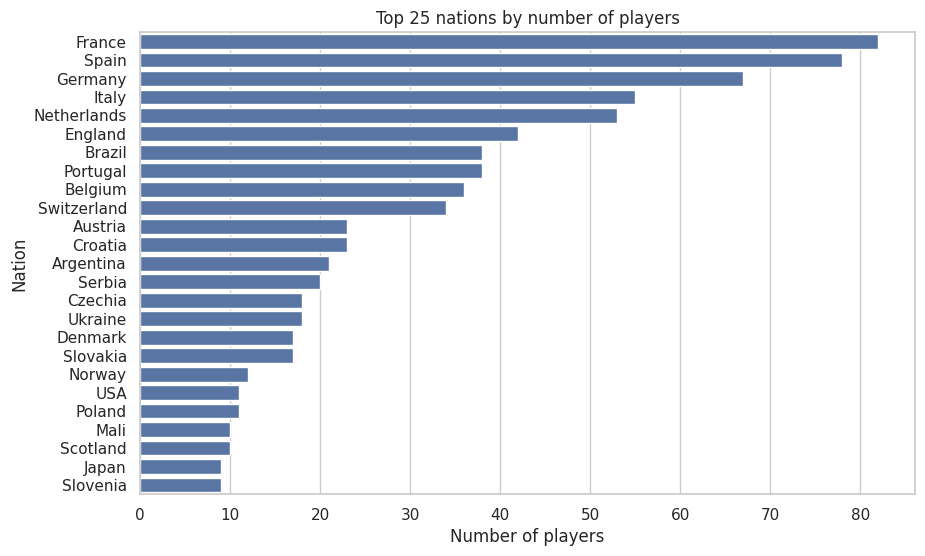

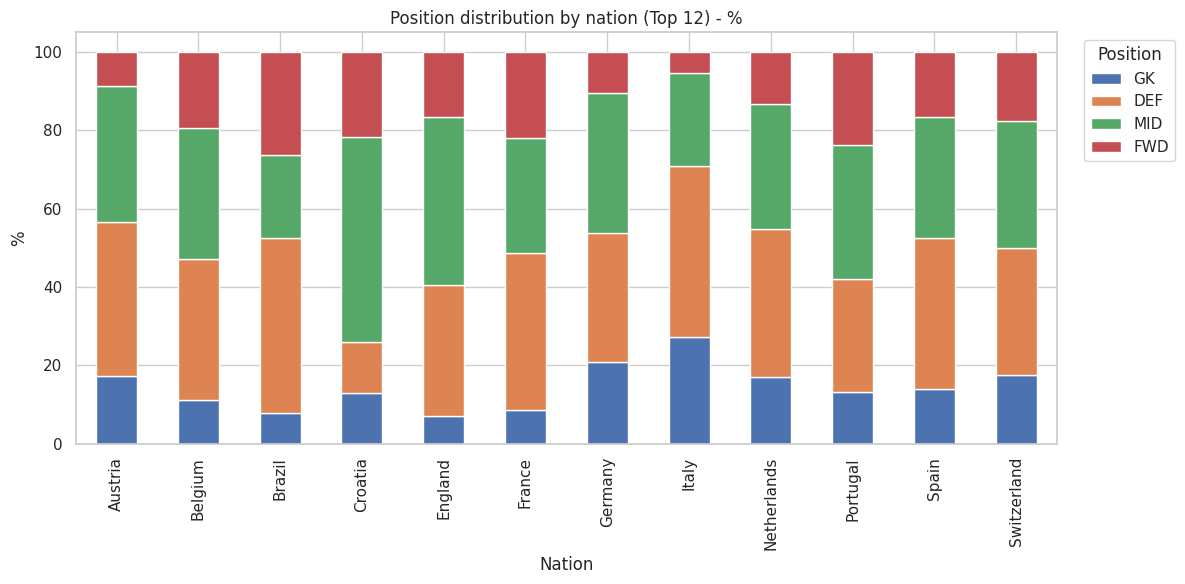

pos_group,GK,DEF,MID,FWD
nationality,,,,
Austria,17.4,39.1,34.8,8.7
Belgium,11.1,36.1,33.3,19.4
Brazil,7.9,44.7,21.1,26.3
Croatia,13.0,13.0,52.2,21.7
England,7.1,33.3,42.9,16.7
France,8.5,40.2,29.3,22.0
Germany,20.9,32.8,35.8,10.4
Italy,27.3,43.6,23.6,5.5
Netherlands,17.0,37.7,32.1,13.2


In [ ]:
country_counts = players_master["nationality"].value_counts().head(25)

plt.figure(figsize=(10,6))
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title("Top 25 nations by number of players")
plt.xlabel("Number of players")
plt.ylabel("Nation")
plt.show()

country_counts.to_frame("players").head(10)

top_n = 12
top_countries = players_master["nationality"].value_counts().head(top_n).index

tmp = players_master[players_master["nationality"].isin(top_countries)]
ct = pd.crosstab(tmp["nationality"], tmp["pos_group"], normalize="index") * 100
ct = ct[["GK","DEF","MID","FWD"]].fillna(0)

ct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title(f"Position distribution by nation (Top {top_n}) - %")
plt.ylabel("%")
plt.xlabel("Nation")
plt.legend(title="Position", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

ct.round(1)


Dob i fizičke karakteristike igrača: usporedba po pozicijama i nacionalnostima

U ovoj sekciji analizira se dobna struktura i fizički profil igrača, s ciljem razumijevanja kako se dob, visina i težina razlikuju između pozicijskih grupa i nacionalnosti.

Analiza uključuje sljedeće korake:

1) Dob igrača po pozicijskim grupama

  * Distribucija dobi prikazana je pomoću boxplot grafa, koji omogućuje usporedbu medijana, raspona i varijabilnosti dobi između različitih pozicija.

  * Dodatno se prikazuje deskriptivna statistika (count, mean, std, kvartili) po pozicijskim grupama, što kvantitativno potvrđuje uočene obrasce.

2) Dob igrača po nacionalnosti (Top nations)

  * Podaci se filtriraju na najzastupljenije nacionalnosti u uzorku (Top countries), uz uklanjanje zapisa bez informacije o dobi.

  * Boxplot omogućuje usporedbu dobnih profila između različitih nogometnih zemalja te identifikaciju potencijalno “mlađih” ili “starijih” tržišta.

3) Težina po pozicijama (ako je dostupno)

  * Ako je stupac weight (kg) prisutan, prikazuje se distribucija težine po pos_group.

  * Ova analiza pomaže razumjeti fizičke zahtjeve i tipične tjelesne profile pojedinih pozicija.

4) Visina po pozicijama (ako je dostupno)

  * Ako je dostupan stupac height (cm), prikazuje se distribucija visine po pozicijama.

  * Vizualizacija ističe očekivane razlike, poput veće prosječne visine kod golmana i stopera.

Ova sekcija pruža važan kontekst za:

  * interpretaciju performansnih metrika u odnosu na dob i fizičke karakteristike,

  * razumijevanje selekcijskih i taktičkih obrazaca po pozicijama,

  * usporedbu profila igrača između različitih nacionalnih tržišta.

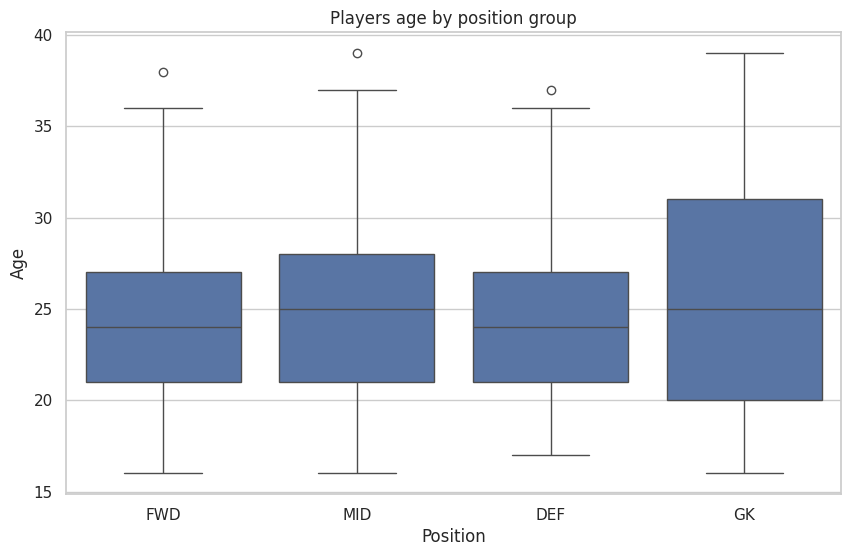

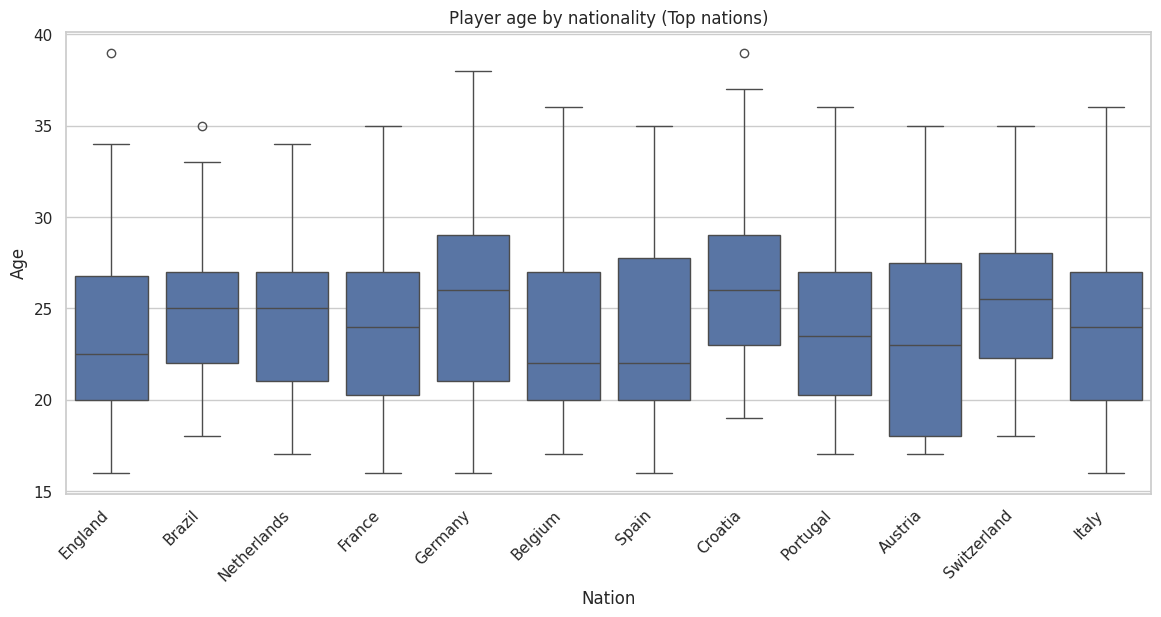

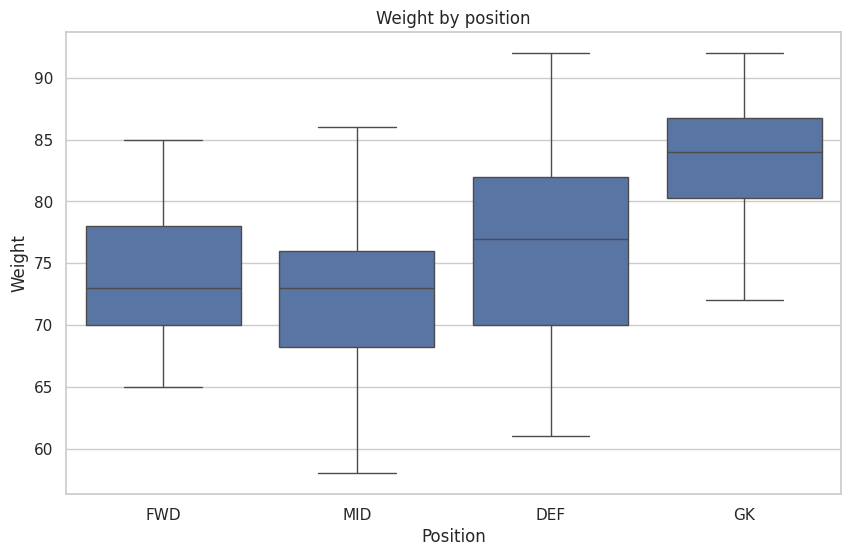

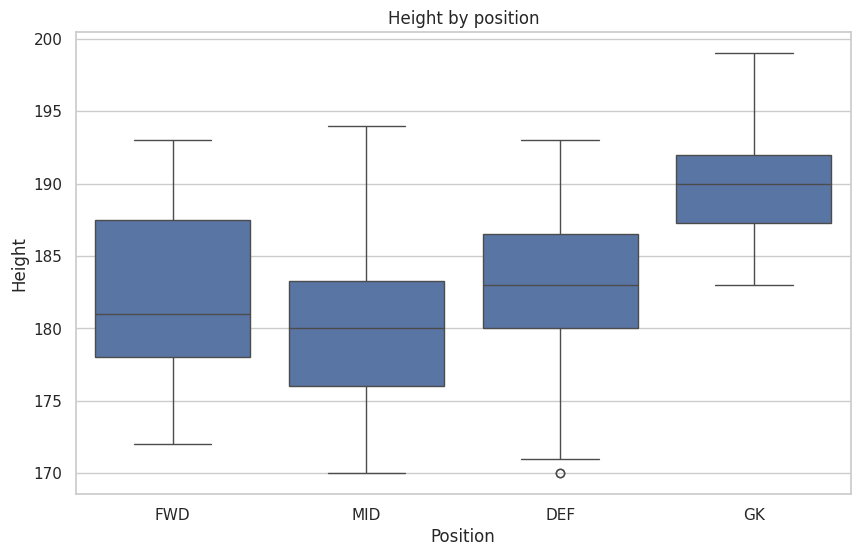

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=players_master, x="pos_group", y="age")
plt.title("Players age by position group")
plt.xlabel("Position")
plt.ylabel("Age")
plt.show()

players_master.groupby("pos_group")["age"].describe()

tmp = players_master[players_master["nationality"].isin(top_countries)].dropna(subset=["age"])

plt.figure(figsize=(14,6))
sns.boxplot(data=tmp, x="nationality", y="age")
plt.title("Player age by nationality (Top nations)")
plt.xlabel("Nation")
plt.ylabel("Age")
plt.xticks(rotation=45, ha="right")
plt.show()

if "weight(kg)" in players_master.columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(data=players_master, x="pos_group", y="weight(kg)")
    plt.title("Weight by position")
    plt.xlabel("Position")
    plt.ylabel("Weight")
    plt.show()

if "height(cm)" in players_master.columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(data=players_master, x="pos_group", y="height(cm)")
    plt.title("Height by position")
    plt.xlabel("Position")
    plt.ylabel("Height")
    plt.show()




Heatmap nacionalne strukture igrača po klubovima

U ovom dijelu analize prikazuje se raspodjela nacionalnosti igrača unutar najzastupljenijih klubova, s ciljem vizualnog uvida u razinu internacionalizacije i strukturu kadra po momčadima.

Postupak uključuje:

  * Identifikaciju Top 15 klubova prema broju igrača u datasetu

  * Identifikaciju Top 15 nacionalnosti prema ukupnoj zastupljenosti

  * Filtriranje podataka na presjek tih klubova i nacionalnosti

  * Izradu kontingencijske (crosstab) tablice koja prikazuje broj igrača po kombinaciji klub–nacionalnost

  * Vizualizaciju rezultata pomoću heatmap grafa

Heatmap omogućuje:

  * brzu identifikaciju dominantnih nacionalnosti unutar pojedinih klubova,

  * usporedbu razine internacionalne raznolikosti između klubova,

  * uočavanje obrazaca (npr. klubovi s jakom domaćom bazom vs. klubovi s izrazito međunarodnim sastavom).

Ovakav prikaz posebno je koristan za:

  * analizu tržišnih i skauting strategija klubova,

  * kontekstualizaciju performansi po nacionalnosti,

  * razumijevanje kulturne i taktičke raznolikosti unutar momčadi.

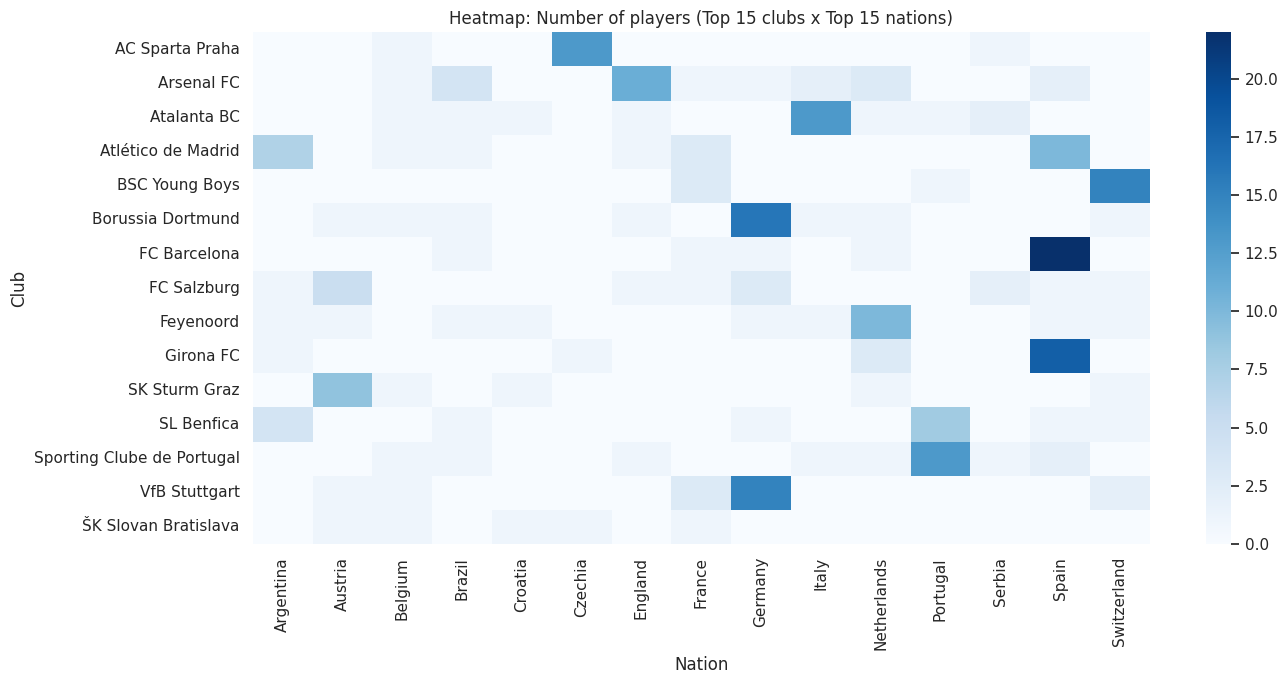

In [ ]:
top_teams = players_master["team"].value_counts().head(15).index
top_nat = players_master["nationality"].value_counts().head(15).index

tmp = players_master[players_master["team"].isin(top_teams) & players_master["nationality"].isin(top_nat)]
mat = pd.crosstab(tmp["team"], tmp["nationality"])

plt.figure(figsize=(14,7))
sns.heatmap(mat, cmap="Blues")
plt.title("Heatmap: Number of players (Top 15 clubs x Top 15 nations)")
plt.xlabel("Nation")
plt.ylabel("Club")
plt.tight_layout()
plt.show()


Struktura klubova po ligama (fallback: država kluba)

U ovoj sekciji analizira se raspodjela klubova po ligama, s ciljem razumijevanja kako su klubovi u datasetu raspoređeni po natjecanjima. U slučajevima kada informacija o ligi nije dostupna, kao fallback se koristi država kluba.

Postupak uključuje:

  * Kopiranje izvornog skupa podataka o klubovima (teams_data)

  * Definiranje varijable league_used, koja:

    * koristi naziv lige ako je dostupan,

    * u suprotnom koristi državu kluba (team country) kao zamjensku vrijednost

  * Izračun broja klubova po ligi/državi

  * Izdvajanje Top 25 liga/država prema broju klubova

  * Vizualizaciju rezultata pomoću horizontalnog stupčastog grafikona

Ova analiza omogućuje:

  * brzi pregled koje su lige najzastupljenije u datasetu,

  * identifikaciju potencijalne pristranosti uzorka prema određenim natjecanjima,

  * kontekst za interpretaciju svih kasnijih analiza na razini klubova i liga.

Tablični ispis ispod grafa dodatno prikazuje točne numeričke vrijednosti za najzastupljenije lige/države.

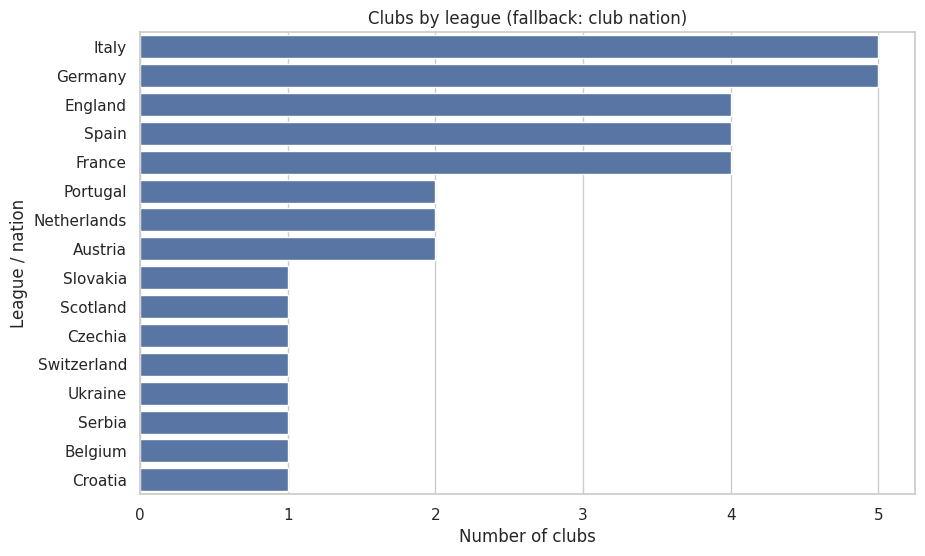

,count
league_used,
Italy,5
Germany,5
England,4
Spain,4
France,4
Portugal,2
Netherlands,2
Austria,2
Slovakia,1


In [ ]:
teams_tmp = teams_data.copy()
teams_tmp["league_used"] = teams_tmp[LEAGUE_COL] if LEAGUE_COL else teams_tmp[TEAM_COUNTRY]

league_counts = teams_tmp["league_used"].value_counts().head(25)

plt.figure(figsize=(10,6))
sns.barplot(x=league_counts.values, y=league_counts.index)
plt.title("Clubs by league (fallback: club nation)")
plt.xlabel("Number of clubs")
plt.ylabel("League / nation")
plt.show()

league_counts.head(10)


Priprema “scoring” tablice: spajanje golova i šuteva u jedinstveni dataset

U ovom koraku izrađuje se osnovna tablica scoring koja objedinjavanjem više izvora stvara jedinstven pregled ofenzivnih metrika po igraču. Tablica služi kao temelj za sve kasnije analize golova, tipova završnice, udaljenosti šuta i preciznosti udaraca.

Postupak uključuje:

  * Identifikaciju odgovarajućeg stupca za ID igrača u datasetima o golovima (goals_data) i šutevima (attempts_data) pomoću funkcije coalesce_col() (zbog mogućih varijacija naziva ID stupca).

  * Inicijalizaciju početne tablice iz players_master s ključnim kontekstualnim varijablama:

      * ime igrača, klub, liga, nacionalnost i pozicijska grupa

  * Spajanje (merge) podataka o:

      * golovima (ukupno, po tipu završnice, po zoni – unutra/izvana kaznenog prostora)

      * pokušajima udaraca (ukupno, u okvir, izvan okvira, blokirano)

  * Standardizaciju numeričkih stupaca: sve relevantne scoring metrike se pretvaraju u numerički format, a nedostajuće vrijednosti popunjavaju se nulama radi konzistentnih agregacija i izračuna u nastavku analize.

Na kraju se prikazuje prvih nekoliko redaka tablice (scoring.head()) kako bi se provjerilo da su spajanja uspješna i da su ključne metrike ispravno pripremljene za daljnju analizu.

In [ ]:
G_PID = coalesce_col(goals_data, ["id_player", "player_id", "id"])
A_PID = coalesce_col(attempts_data, ["id_player", "player_id", "id"])

scoring = players_master[[P_ID, "player_name", "team", "league", "nationality", "pos_group"]].copy()

# merge goals
if G_PID:
    scoring = scoring.merge(goals_data, left_on=P_ID, right_on=G_PID, how="left", suffixes=("", "_goals"))

# merge attempts
if A_PID:
    scoring = scoring.merge(attempts_data, left_on=P_ID, right_on=A_PID, how="left", suffixes=("", "_att"))

# fill numeric NaNs with 0 for relevant scoring cols if present
num_cols = [
    "goals","inside_area","outside_area","right_foot","left_foot","head","other","penalties_scored",
    "total_attempts","attempts_on_target","attempts_off_target","blocked"
]
for c in num_cols:
    if c in scoring.columns:
        scoring[c] = pd.to_numeric(scoring[c], errors="coerce").fillna(0)

scoring.head()


,id_player,player_name,team,league,nationality,pos_group,goals,inside_area,outside_area,right_foot,left_foot,head,other,penalties_scored,total_attempts,attempts_on_target,attempts_off_target,blocked
0,250016833,Harry Kane,FC Bayern München,Germany,England,FWD,5.0,5.0,0.0,5.0,0.0,0.0,0.0,3.0,20.0,12.0,6.0,2.0
1,250105927,Viktor Gyökeres,Sporting Clube de Portugal,Portugal,Sweden,FWD,5.0,5.0,0.0,5.0,0.0,0.0,0.0,2.0,15.0,8.0,3.0,4.0
2,250121533,Vinícius Júnior,Real Madrid C.F.,Spain,Brazil,FWD,4.0,3.0,1.0,2.0,2.0,0.0,0.0,1.0,17.0,10.0,6.0,1.0
3,250121294,Tijjani Reijnders,AC Milan,Italy,Netherlands,MID,3.0,3.0,0.0,2.0,1.0,0.0,0.0,0.0,8.0,5.0,1.0,2.0
4,250160436,Maghnes Akliouche,AS Monaco,France,France,MID,2.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,10.0,4.0,3.0,3.0


Analiza golova: klubovi, nacionalnosti, tipovi završnice, udaljenost i preciznost udaraca

U ovoj sekciji radi se sveobuhvatna analiza golgeterskog outputa na više razina (momčad, nacionalnost, pozicija) te se dodatno istražavaju tipovi postignutih golova, zona šuta (unutra/izvan kaznenog prostora) i preciznost udaraca.

Obrada je organizirana u nekoliko koraka:

1) Top 20 klubova i nacionalnosti po broju golova

  * Podaci se agregiraju zbrajanjem golova po klubu i po nacionalnosti.

  * Prikazuju se Top 20 kategorija u oba slučaja, uz vizualizaciju horizontalnim stupčastim grafovima.
Ovo daje brzu sliku o tome koje momčadi i koje nogometne zemlje imaju najveći golgeterski doprinos u uzorku.

2) Golovi prema tipu završnice (goal type)
Ako su dostupni stupci (npr. right_foot, left_foot, head, penalties_scored, other), izračunava se ukupni broj golova po tipu te se prikazuje graf koji pokazuje:

  * dominantne načine završnice u uzorku,

  * odnos golova iz igre i iz kaznenih udaraca,

  * strukturu golova prema načinu udarca.

3) Golovi prema udaljenosti (zona šuta)
Ako postoje stupci inside_area i outside_area, zbrajaju se golovi iz:

  * kaznenog prostora (inside_area)

  * izvan kaznenog prostora (outside_area)
      * Vizualizacija omogućuje uvid u to dolazi li većina golova iz blizine gola ili iz daljine.

4) Golovi po pozicijskim grupama
Golovi se agregiraju po pos_group i prikazuju stupčastim grafom. Ovaj dio pomaže kontekstualizirati očekivani doprinos različitih uloga na terenu (npr. napadači vs. vezni/obrambeni).

5) Distribucija golova među napadačima (FWD)
Za pozicijsku grupu FWD prikazuje se raspodjela broja postignutih golova (0, 1, 2, …). Ova distribucija pokazuje:

  * koliko je golova “raspršeno” među napadačima,

  * postoji li koncentracija na mali broj izrazito učinkovitih strijelaca.

6) Preciznost udaraca (shot accuracy)
Ako su dostupni stupci total_attempts i attempts_on_target, računa se metrika:

shot_accuracy = attempts_on_target / total_attempts

Kako bi rezultati bili stabilniji, analiza se ograničava na igrače s ≥ 10 udaraca, zatim se izdvajaju Top 20 najpreciznijih i prikazuju na grafu (u postocima). Uz graf se prikazuje i tablica s ključnim vrijednostima (pokušaji, udarci u okvir i izračunata preciznost).

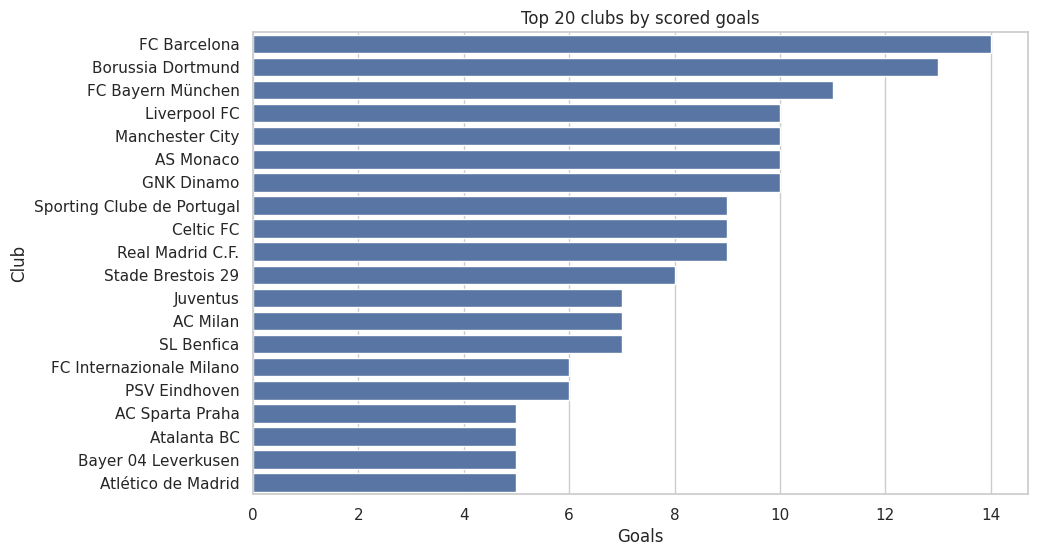

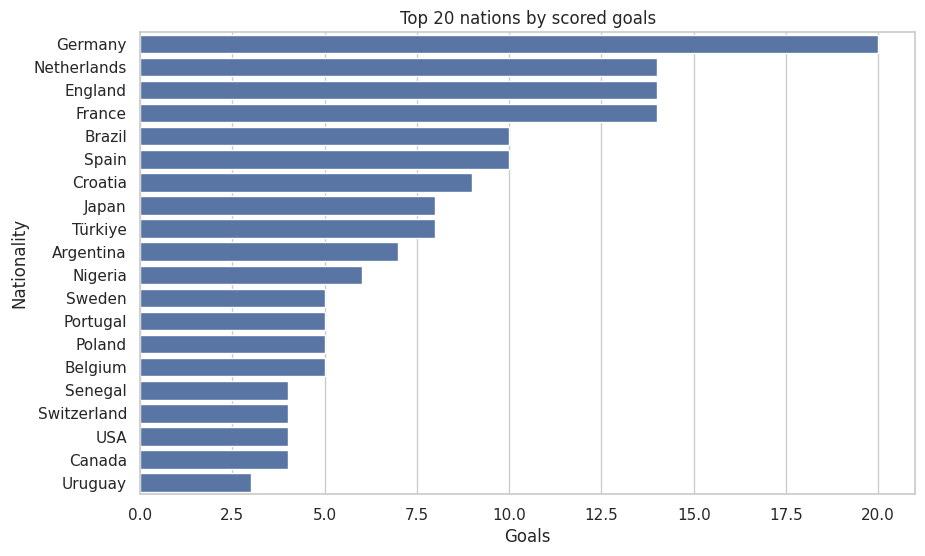

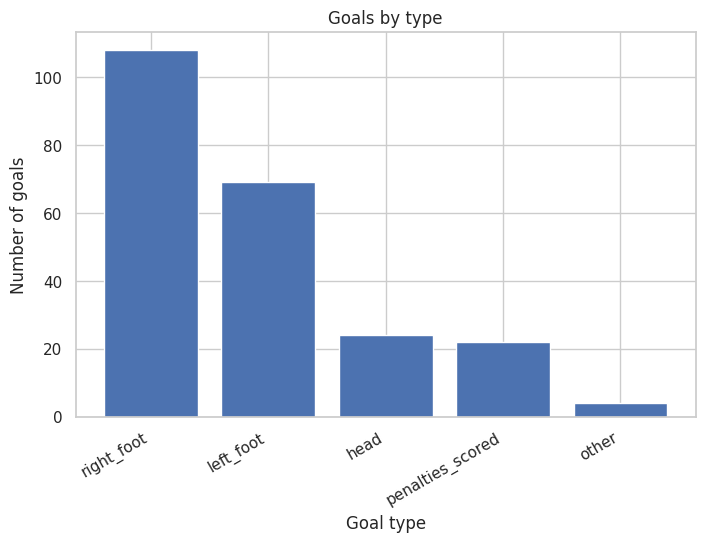

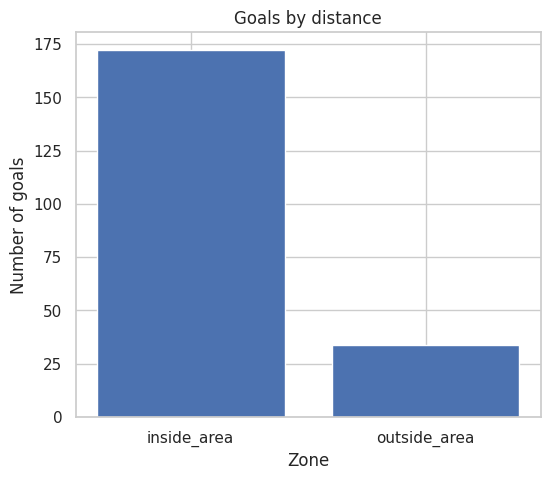

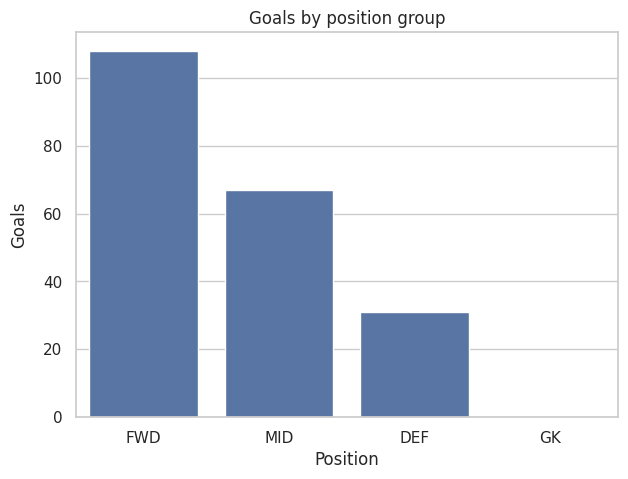

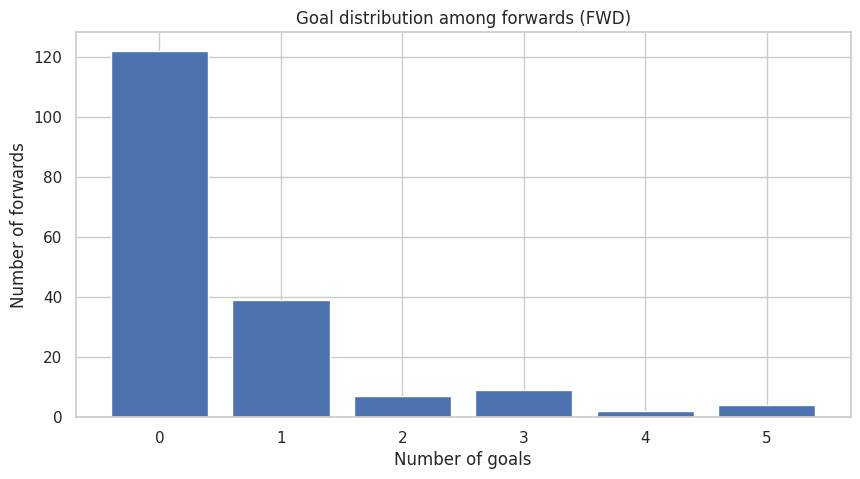

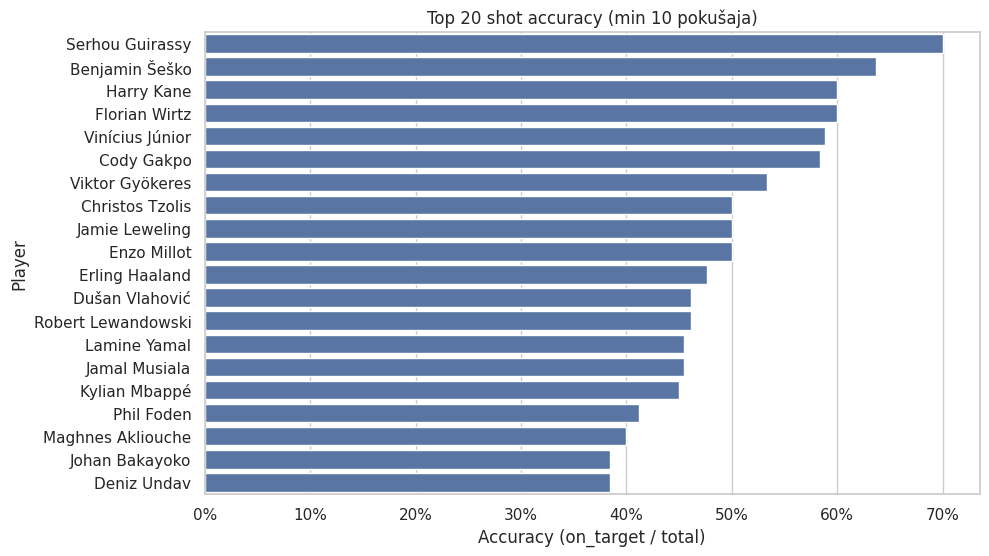

In [ ]:
g_by_team = scoring.groupby("team")["goals"].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=g_by_team.values, y=g_by_team.index)
plt.title("Top 20 clubs by scored goals")
plt.xlabel("Goals")
plt.ylabel("Club")
plt.show()

g_by_team

g_by_nat = scoring.groupby("nationality")["goals"].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=g_by_nat.values, y=g_by_nat.index)
plt.title("Top 20 nations by scored goals")
plt.xlabel("Goals")
plt.ylabel("Nationality")
plt.show()

type_cols = ["right_foot","left_foot","penalties_scored","head","other"]
present = [c for c in type_cols if c in scoring.columns]

type_totals = scoring[present].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(type_totals.index, type_totals.values)
plt.title("Goals by type")
plt.xlabel("Goal type")
plt.ylabel("Number of goals")
plt.xticks(rotation=30, ha="right")
plt.show()

type_totals

if "inside_area" in scoring.columns and "outside_area" in scoring.columns:
    dist_totals = scoring[["inside_area","outside_area"]].sum()

    plt.figure(figsize=(6,5))
    plt.bar(dist_totals.index, dist_totals.values)
    plt.title("Goals by distance")
    plt.xlabel("Zone")
    plt.ylabel("Number of goals")
    plt.show()

    dist_totals

    g_by_pos = scoring.groupby("pos_group")["goals"].sum().sort_values(ascending=False)

plt.figure(figsize=(7,5))
sns.barplot(x=g_by_pos.index, y=g_by_pos.values)
plt.title("Goals by position group")
plt.xlabel("Position")
plt.ylabel("Goals")
plt.show()

g_by_pos

fwd = scoring[scoring["pos_group"] == "FWD"].copy()
fwd_goal_dist = fwd["goals"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(fwd_goal_dist.index.astype(int), fwd_goal_dist.values)
plt.title("Goal distribution among forwards (FWD)")
plt.xlabel("Number of goals")
plt.ylabel("Number of forwards")
plt.xticks(fwd_goal_dist.index.astype(int))
plt.show()

fwd_goal_dist.head(15)

if "total_attempts" in scoring.columns and "attempts_on_target" in scoring.columns:
    scoring["shot_accuracy"] = np.where(
        scoring["total_attempts"] > 0,
        scoring["attempts_on_target"] / scoring["total_attempts"],
        np.nan
    )

    top_acc = scoring.loc[scoring["total_attempts"] >= 10].sort_values("shot_accuracy", ascending=False).head(20)

    plt.figure(figsize=(10,6))
    sns.barplot(data=top_acc, x="shot_accuracy", y="player_name")
    plt.title("Top 20 shot accuracy (min 10 pokušaja)")
    plt.xlabel("Accuracy (on_target / total)")
    plt.ylabel("Player")
    plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.show()

    top_acc[["player_name","team","total_attempts","attempts_on_target","shot_accuracy"]].head(20)


Asistencije: doprinos kreaciji prilika po klubovima, nacionalnostima i pozicijama

U ovoj sekciji analizira se broj asistencija kao mjera kreativnog ofenzivnog doprinosa igrača. Podaci iz attacking skupa spajaju se s master tablicom igrača kako bi se zadržao kontekst (klub, liga, nacionalnost i pozicijska grupa).

Postupak uključuje:

  * Spajanje tablice igrača s attacking podacima prema ID-u igrača

  * Pretvaranje stupca assists u numerički format i popunjavanje nedostajućih vrijednosti nulama

  * Agregaciju asistencija na različitim razinama i vizualizaciju rezultata

Analize koje se prikazuju:

1. Top 20 klubova po ukupnom broju asistencija
Zbrajanjem asistencija po klubu dobiva se uvid u momčadi s najvećim kreativnim outputom u promatranom uzorku.

2. Top 20 nacionalnosti po ukupnom broju asistencija
Agregacija po nacionalnosti omogućuje usporedbu profila kreativnosti između različitih nogometnih zemalja.

3. Asistencije po pozicijskim grupama
Zbroj asistencija po pos_group prikazuje koje pozicije u ukupnom zbroju najviše doprinose kreaciji (očekivano češće vezni i krilni profili).

4. Distribucija asistencija među napadačima (FWD)
Za pozicijsku grupu FWD analizira se raspodjela broja asistencija (0, 1, 2, 3, …) kako bi se vidjelo koliko je kreativni doprinos napadača koncentriran na manji broj igrača ili ravnomjernije raspodijeljen.

Ova sekcija pomaže identificirati:

  * klubove i nacionalnosti s izrazito kreativnim profilom,

  * pozicijske uloge koje nose najveći asistentski teret,

  * te strukturu kreativnog doprinosa unutar skupine napadača.

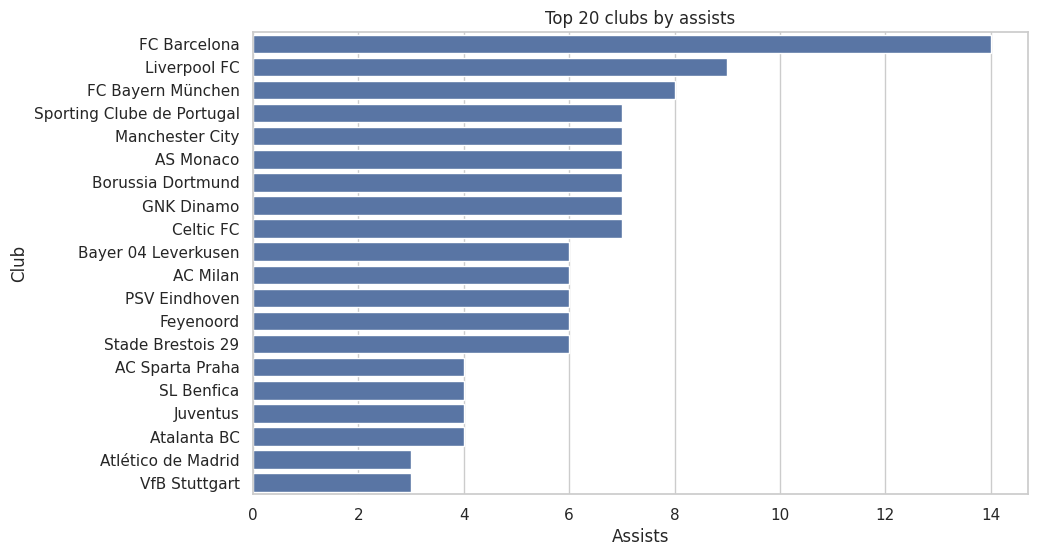

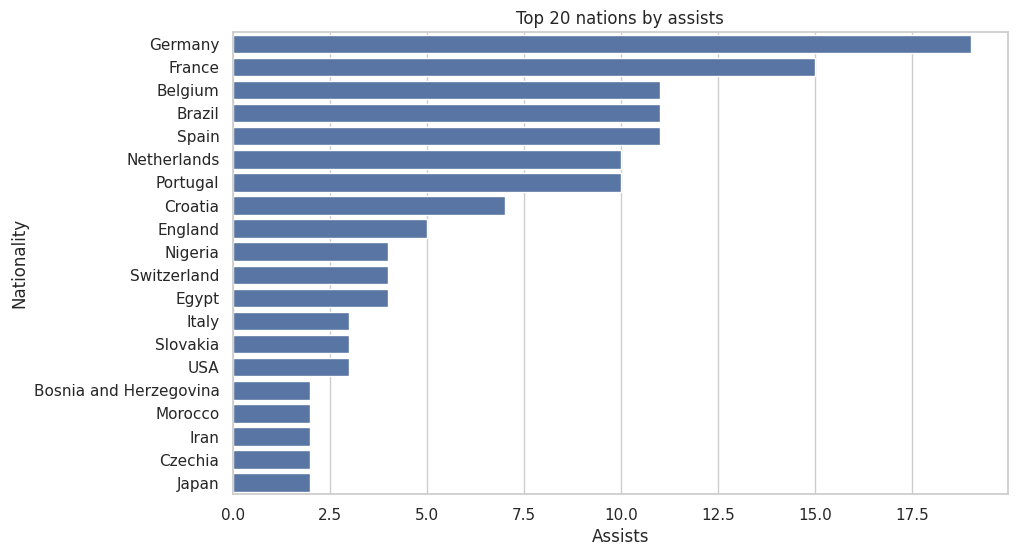

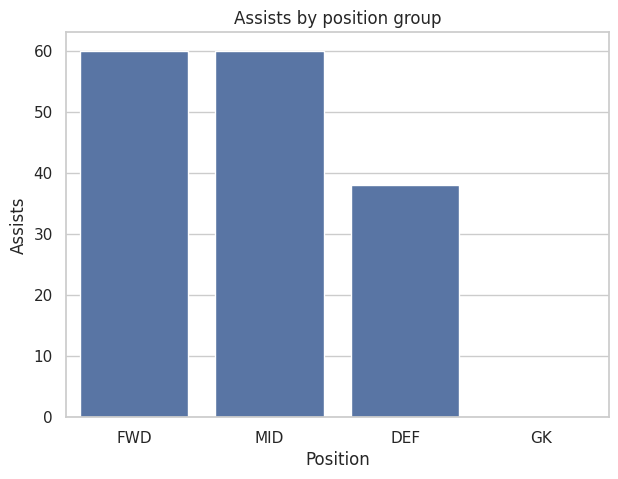

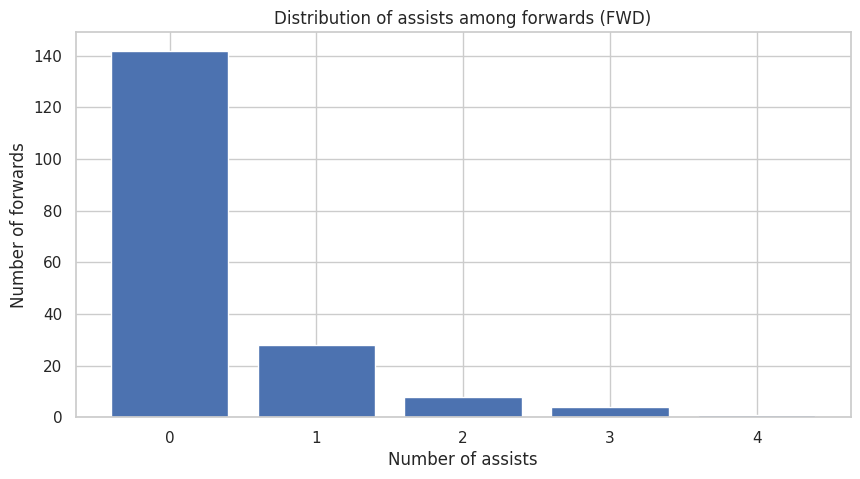

In [ ]:
AT_PID = coalesce_col(attacking_data, ["id_player", "player_id", "id"])

assist = players_master[[P_ID, "player_name", "team", "league", "nationality", "pos_group"]].merge(
    attacking_data, left_on=P_ID, right_on=AT_PID, how="left"
)

if "assists" in assist.columns:
    assist["assists"] = pd.to_numeric(assist["assists"], errors="coerce").fillna(0)

# assists by club
a_by_team = assist.groupby("team")["assists"].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=a_by_team.values, y=a_by_team.index)
plt.title("Top 20 clubs by assists")
plt.xlabel("Assists")
plt.ylabel("Club")
plt.show()

# assists by nationality
a_by_nat = assist.groupby("nationality")["assists"].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=a_by_nat.values, y=a_by_nat.index)
plt.title("Top 20 nations by assists")
plt.xlabel("Assists")
plt.ylabel("Nationality")
plt.show()

# assists by position group
a_by_pos = assist.groupby("pos_group")["assists"].sum().sort_values(ascending=False)
plt.figure(figsize=(7,5))
sns.barplot(x=a_by_pos.index, y=a_by_pos.values)
plt.title("Assists by position group")
plt.xlabel("Position")
plt.ylabel("Assists")
plt.show()

# distribution among forwards: 1,2,3...
fwd_a = assist[assist["pos_group"]=="FWD"]["assists"].value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.bar(fwd_a.index.astype(int), fwd_a.values)
plt.title("Distribution of assists among forwards (FWD)")
plt.xlabel("Number of assists")
plt.ylabel("Number of forwards")
plt.xticks(fwd_a.index.astype(int))
plt.show()


Minutaža igrača: distribucija vremena igre po pozicijama

U ovoj sekciji analizira se raspodjela odigranih minuta kao pokazatelj uloge i kontinuiteta igrača unutar momčadi. Podaci o minutaži preuzimaju se iz key stats skupa podataka i spajaju s master tablicom igrača radi dodavanja konteksta (pozicija, tim, nacionalnost).

Postupak uključuje:

  * Spajanje tablice igrača s podacima o minutaži pomoću ID-a igrača

  * Automatsko prepoznavanje stupca s brojem nastupa (matches played), uključujući moguće varijacije u nazivu stupca

  * Standardizaciju numeričkih vrijednosti za minutes played

  * Vizualizaciju distribucije minutaže po pozicijskim grupama

Distribucija je prikazana pomoću boxplot grafa, koji omogućuje:

  * usporedbu tipičnog vremena igre između pozicija,

  * uvid u raspon i varijabilnost minutaže,

  * identifikaciju outliera (igrača s izrazito velikom ili malom minutažom).

Dodatno, deskriptivna statistika (count, mean, median, kvartili) po pozicijskim grupama daje kvantitativni sažetak vremena igre i potvrđuje vizualne obrasce uočene na grafu.

Ova analiza pomaže razumjeti:

  * strukturne razlike u rotaciji između pozicija,

  * koje pozicije u prosjeku imaju najveću minutažu,

  * te kontekst za interpretaciju svih ostalih per-90 metrika korištenih u analizi.

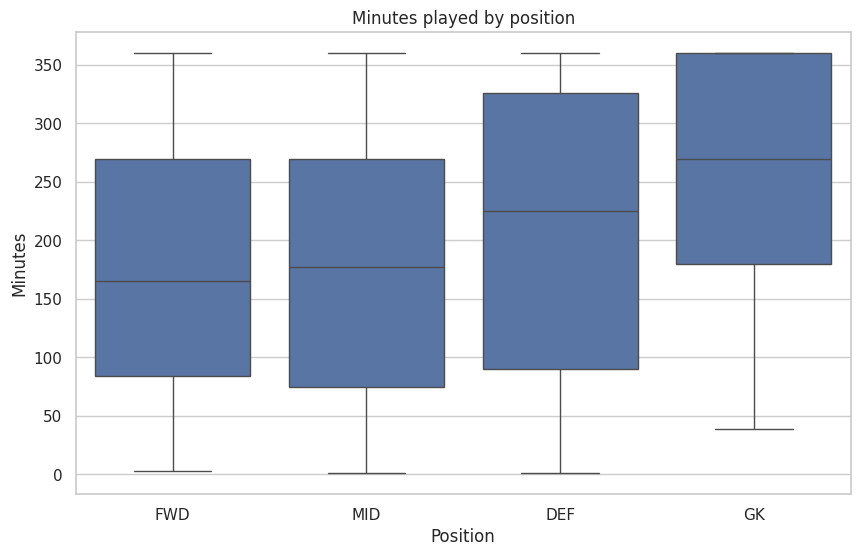

,count,mean,std,min,25%,50%,75%,max
pos_group,,,,,,,,
DEF,247.0,204.878543,123.230176,1.0,90.0,225.0,326.0,360.0
FWD,163.0,173.447853,109.174068,3.0,84.0,165.0,270.0,360.0
GK,51.0,246.980392,108.867349,39.0,180.0,270.0,360.0,360.0
MID,266.0,176.575188,115.380862,1.0,74.5,177.5,270.0,360.0


In [ ]:
KS_PID = coalesce_col(key_stats_data, ["id_player", "player_id", "id"])

minutes = players_master[[P_ID, "player_name", "team", "nationality", "pos_group"]].merge(
    key_stats_data, left_on=P_ID, right_on=KS_PID, how="left"
)

# handle possible typo: matches_appareance vs matches_appearance
matches_col = coalesce_col(minutes, ["matches_appareance", "matches_appearance", "matches_played"])
if matches_col:
    minutes[matches_col] = pd.to_numeric(minutes[matches_col], errors="coerce")

if "minutes_played" in minutes.columns:
    minutes["minutes_played"] = pd.to_numeric(minutes["minutes_played"], errors="coerce")

plt.figure(figsize=(10,6))
sns.boxplot(data=minutes, x="pos_group", y="minutes_played")
plt.title("Minutes played by position")
plt.xlabel("Position")
plt.ylabel("Minutes")
plt.show()

minutes.groupby("pos_group")["minutes_played"].describe()


Učinkovitost dodavanja: točnost dodavanja po klubovima, nacionalnostima i pozicijama

U ovoj sekciji analizira se točnost dodavanja (passing accuracy) kao osnovni pokazatelj tehničke kvalitete i stila igre. Podaci o distribuciji dodavanja spajaju se s master tablicom igrača kako bi se zadržao kontekst (klub, liga, nacionalnost i pozicijska grupa).

Postupak uključuje:

  * Spajanje (merge) tablice igrača s distribution skupom podataka prema ID-u igrača

  * Pretvaranje relevantnih stupaca u numerički format (passes attempted, passes completed, passing accuracy)

  * Ako izvorni stupac passing_accuracy(%) nije dostupan, točnost se računa iz pokušaja i uspješnih dodavanja:

    * passing accuracy = passes_completed / passes_attempted × 100

  * Uklanjanje zapisa bez valjanih vrijednosti točnosti dodavanja

Kako bi se izbjegla pristranost zbog premalog uzorka, u analizi se koriste pragovi minimalnog volumena dodavanja:

1. Top klubovi po prosječnoj točnosti (min 300 pokušaja)
Za svaki klub računa se prosječna točnost dodavanja te ukupan broj pokušaja. U usporedbu ulaze samo klubovi s ≥ 300 pokušaja, nakon čega se prikazuje Top 20 klubova po prosječnoj točnosti.

2. Prosječna točnost po nacionalnosti
Izračunava se prosječna passing accuracy po nacionalnosti, čime se dobiva uvid u razlike u profilu igrača između različitih nogometnih zemalja (Top 20).

3. Najprecizniji igrači (min 200 pokušaja)
Izdvajaju se igrači s ≥ 200 pokušaja dodavanja te se rangiraju prema točnosti, kako bi se identificirali pojedinci s visokom preciznošću uz dovoljno velik uzorak.

4. Razlike po pozicijskim grupama
Boxplot prikazuje distribuciju passing accuracy po pos_group, što omogućuje usporedbu tipičnih vrijednosti i varijabilnosti između pozicija (npr. obrambeni vs. vezni vs. napadački profili).

Ova analiza pomaže razumjeti:

  * koje momčadi imaju najvišu tehničku razinu u posjedu,

  * kako se preciznost razlikuje među nacionalnostima,

  * te koji pojedinci i pozicije u prosjeku ostvaruju najvišu točnost dodavanja.

/tmp/ipython-input-2645981432.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  club_acc = tmp.groupby("team").apply(


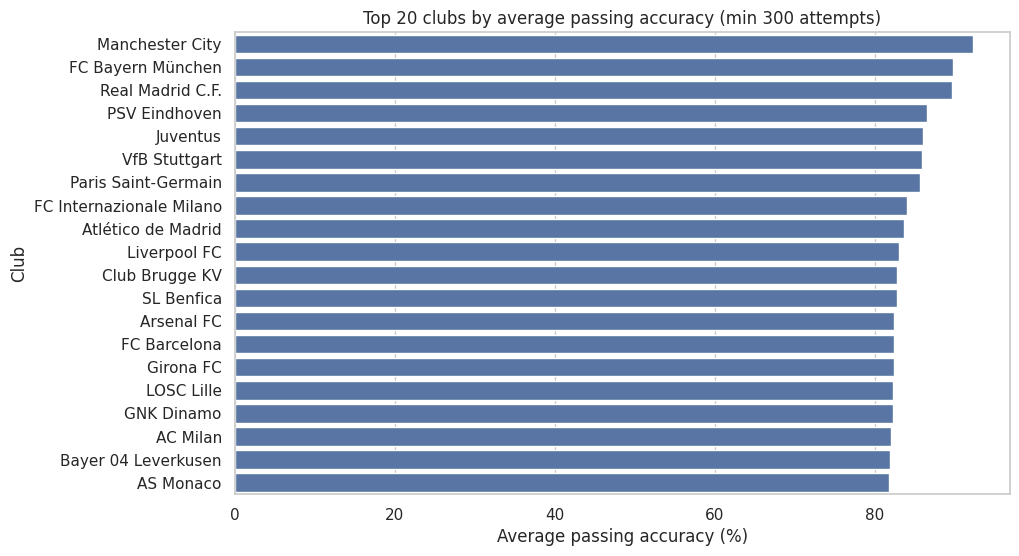

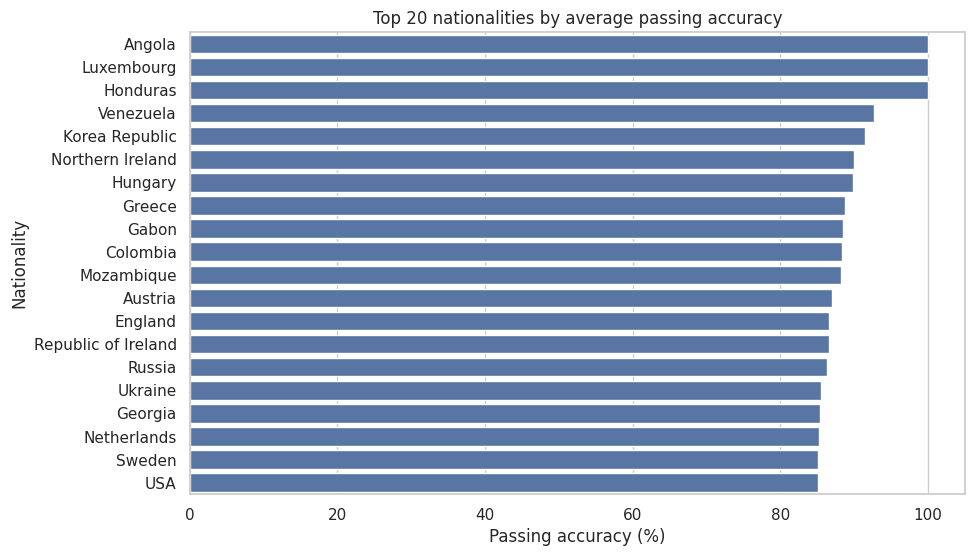

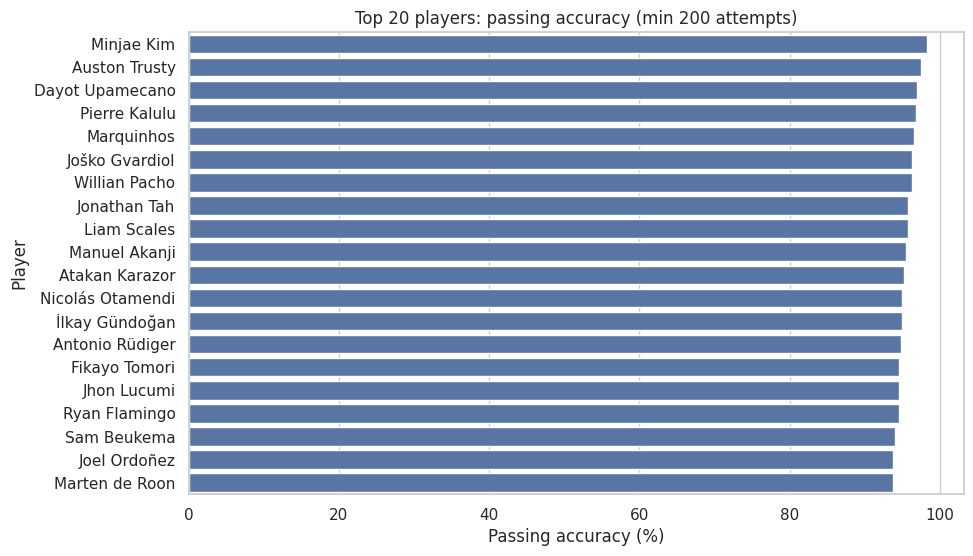

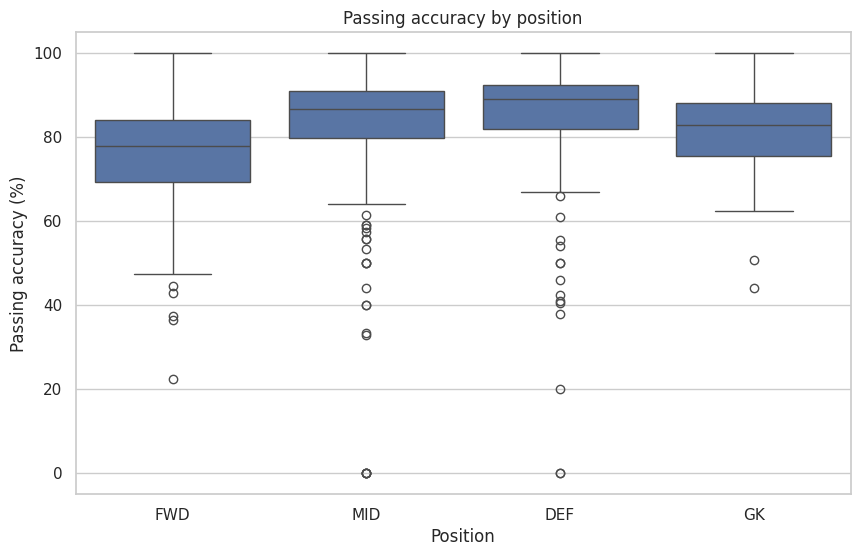

In [ ]:
D_PID = coalesce_col(distribution_data, ["id_player", "player_id", "id"])

passing = players_master[[P_ID, "player_name", "team", "league", "nationality", "pos_group"]].merge(
    distribution_data, left_on=P_ID, right_on=D_PID, how="left"
)

# numeric
for c in ["passes_attempted","passes_completed","passing_accuracy(%)"]:
    if c in passing.columns:
        passing[c] = pd.to_numeric(passing[c], errors="coerce")

# If accuracy column missing, compute it
if "passing_accuracy(%)" not in passing.columns and "passes_attempted" in passing.columns and "passes_completed" in passing.columns:
    passing["passing_accuracy(%)"] = np.where(
        passing["passes_attempted"] > 0,
        100 * passing["passes_completed"] / passing["passes_attempted"],
        np.nan
    )

# By club: avg accuracy (min attempts)
tmp = passing.dropna(subset=["passing_accuracy(%)"])
club_acc = tmp.groupby("team").apply(
    lambda x: pd.Series({
        "avg_acc": np.nanmean(x["passing_accuracy(%)"]),
        "total_passes": np.nansum(x.get("passes_attempted", 0))
    })
).sort_values("avg_acc", ascending=False)

club_acc_f = club_acc[club_acc["total_passes"] >= 300].head(20)

plt.figure(figsize=(10,6))
sns.barplot(data=club_acc_f, x="avg_acc", y=club_acc_f.index)
plt.title("Top 20 clubs by average passing accuracy (min 300 attempts)")
plt.xlabel("Average passing accuracy (%)")
plt.ylabel("Club")
plt.show()

# By nationality
nat_acc = tmp.groupby("nationality")["passing_accuracy(%)"].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=nat_acc.values, y=nat_acc.index)
plt.title("Top 20 nationalities by average passing accuracy")
plt.xlabel("Passing accuracy (%)")
plt.ylabel("Nationality")
plt.show()

# Most efficient players (min passes attempted)
player_eff = tmp[tmp["passes_attempted"] >= 200].sort_values("passing_accuracy(%)", ascending=False).head(20)
plt.figure(figsize=(10,6))
sns.barplot(data=player_eff, x="passing_accuracy(%)", y="player_name")
plt.title("Top 20 players: passing accuracy (min 200 attempts)")
plt.xlabel("Passing accuracy (%)")
plt.ylabel("Player")
plt.show()

# By position group
plt.figure(figsize=(10,6))
sns.boxplot(data=tmp, x="pos_group", y="passing_accuracy(%)")
plt.title("Passing accuracy by position")
plt.xlabel("Position")
plt.ylabel("Passing accuracy (%)")
plt.show()


Kvaliteta ubačaja: točnost po igračima, klubovima i pozicijama

U ovom dijelu analize ispituje se kvaliteta ubačaja (crossing accuracy) kao važna komponenta ofenzivne igre, posebno za krilne igrače i bekove. Analiza se temelji na podacima iz passing skupa podataka.

Postupak uključuje:

  * Kopiranje i čišćenje passing podataka relevantnih za centaršuteve

  * Standardizaciju numeričkih stupaca (crosses attempted, crosses completed)

  * Izračun točnosti ubačaja (%) u slučajevima gdje izravna metrika nije dostupna:

      * crossing accuracy = completed crosses / attempted crosses × 100

  * Uklanjanje zapisa bez valjanih podataka o točnosti

Kako bi se izbjegli rezultati temeljeni na premalom uzorku, uvode se pragovi minimalnog broja pokušaja:

1. Kvaliteta ubačaja po klubu
Za svaki klub računa se prosječna točnost ubačaja te ukupan broj pokušaja. U analizu ulaze samo klubovi s najmanje 50 pokušaja ubačaja, nakon čega se prikazuje Top 20 klubova prema prosječnoj točnosti.

2. Najbolji izvođači ubačaja
Na razini pojedinaca izdvajaju se igrači s najmanje 30 pokušaja ubačaja, rangirani prema točnosti izvođenja. Ovaj prikaz pomaže identificirati igrače s iznadprosječnom kvalitetom završnog dodavanja s boka.

3. Razlike po pozicijskim grupama
Boxplot vizualizacija prikazuje distribuciju točnosti ubačaja po pozicijskim grupama, omogućujući usporedbu varijabilnosti i tipičnih vrijednosti između obrambenih, veznih i napadačkih uloga.

Ova analiza pruža uvid u:

  * strukturalne razlike u kvaliteti ubačaja između klubova,

  * individualnu tehničku kvalitetu igrača,

  * te očekivane pozicijske profile (npr. bekovi i krila vs. centralni igrači).

/tmp/ipython-input-3753060839.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  club_cross = tmp.groupby("team").apply(


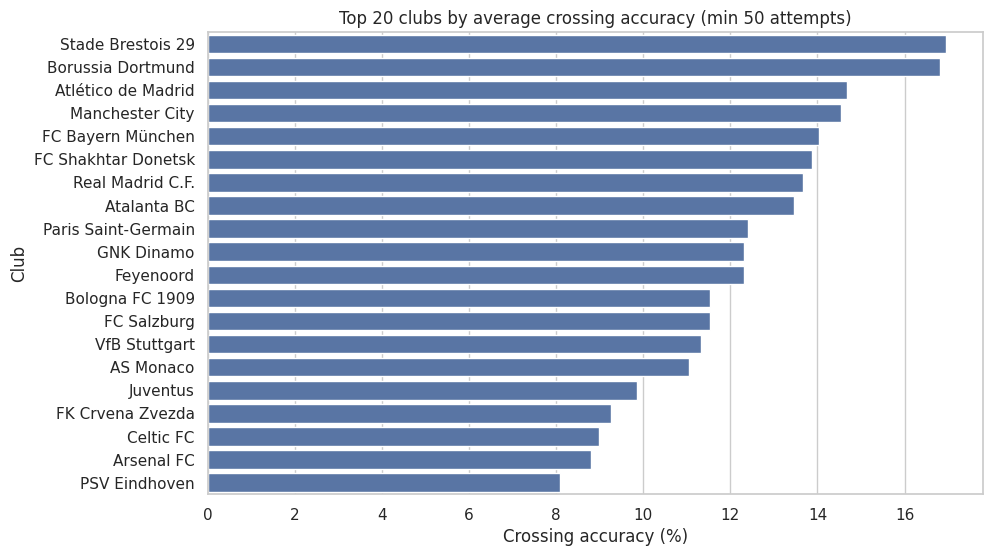

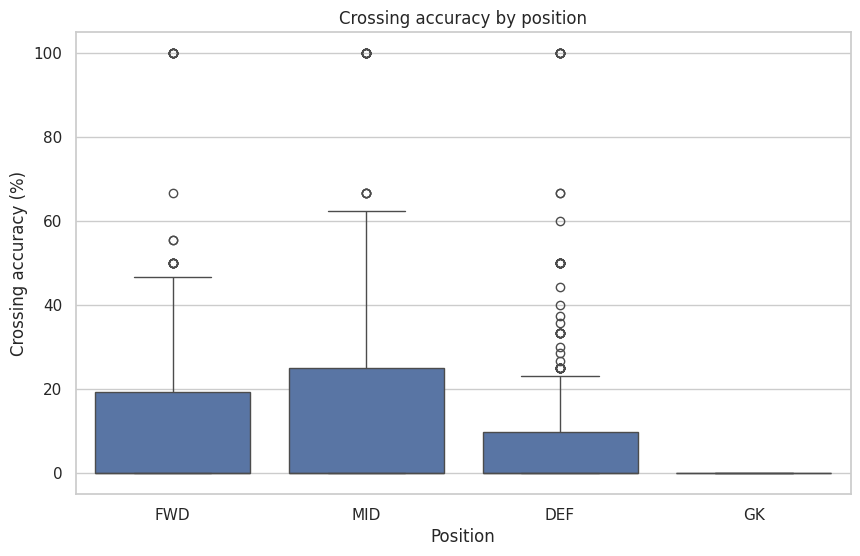

In [ ]:
cross = passing.copy()

for c in ["crosses_attempted","crosses_completed","crossing_accuracy(%)"]:
    if c in cross.columns:
        cross[c] = pd.to_numeric(cross[c], errors="coerce")

if "crossing_accuracy(%)" not in cross.columns and "crosses_attempted" in cross.columns and "crosses_completed" in cross.columns:
    cross["crossing_accuracy(%)"] = np.where(
        cross["crosses_attempted"] > 0,
        100 * cross["crosses_completed"] / cross["crosses_attempted"],
        np.nan
    )

tmp = cross.dropna(subset=["crossing_accuracy(%)"])

# By club (min crosses)
club_cross = tmp.groupby("team").apply(
    lambda x: pd.Series({
        "avg_cross_acc": np.nanmean(x["crossing_accuracy(%)"]),
        "total_crosses": np.nansum(x.get("crosses_attempted", 0))
    })
).sort_values("avg_cross_acc", ascending=False)

club_cross_f = club_cross[club_cross["total_crosses"] >= 50].head(20)

plt.figure(figsize=(10,6))
sns.barplot(data=club_cross_f, x="avg_cross_acc", y=club_cross_f.index)
plt.title("Top 20 clubs by average crossing accuracy (min 50 attempts)")
plt.xlabel("Crossing accuracy (%)")
plt.ylabel("Club")
plt.show()



# By position
plt.figure(figsize=(10,6))
sns.boxplot(data=tmp, x="pos_group", y="crossing_accuracy(%)")
plt.title("Crossing accuracy by position")
plt.xlabel("Position")
plt.ylabel("Crossing accuracy (%)")
plt.show()


Obrambeni učinak: kompozitni defenzivni indeks

U ovoj sekciji analize procjenjuje se obrambeni doprinos igrača korištenjem osnovnih defenzivnih akcija iz defending skupa podataka. Kako bi se dobila jedinstvena i lako interpretabilna mjera, konstruira se defenzivni indeks koji agregira najvažnije obrambene aktivnosti.

Postupak uključuje:

  * Spajanje master tablice igrača s defenzivnim statistikama pomoću ID-a igrača

  * Čišćenje i standardizaciju ključnih defenzivnih varijabli (tackles won, balls recovered, clearances)

  * Izračun defenzivnog indeksa, definiranog kao:

    * def_index = tackles_won + balls_recovered + clearance_attempted

Na temelju ovog indeksa provode se sljedeće analize:

1. Obrambeni učinak po klubu
Zbrajanjem defenzivnog indeksa po klubu izdvajaju se Top 20 klubova s najvećim ukupnim obrambenim doprinosom, što reflektira kombinaciju individualne kvalitete igrača i kolektivne obrambene strukture.

2. Obrambeni učinak po nacionalnosti
Agregacija po nacionalnosti omogućuje usporedbu obrambenih profila različitih zemalja te identifikaciju nacionalnosti s naglašenim defenzivnim karakteristikama.

3. Najistaknutiji obrambeni igrači
Analizom indeksa na razini pojedinaca izdvajaju se Top 20 igrača s najvećim ukupnim obrambenim učinkom, uz zadržavanje klupskog konteksta.

4. Razlike po pozicijskim grupama
Izračunom prosječnog defenzivnog indeksa po pozicijskim grupama dobiva se uvid u to koje pozicije u prosjeku ostvaruju najveći obrambeni doprinos, što potvrđuje očekivane razlike između obrambenih, veznih i napadačkih uloga.

Ovakav kompozitni pristup omogućuje brzu i preglednu procjenu obrambenog učinka, korisnu za skauting, usporedbu profila igrača te analizu stilova igre između klubova, liga i nacionalnosti.

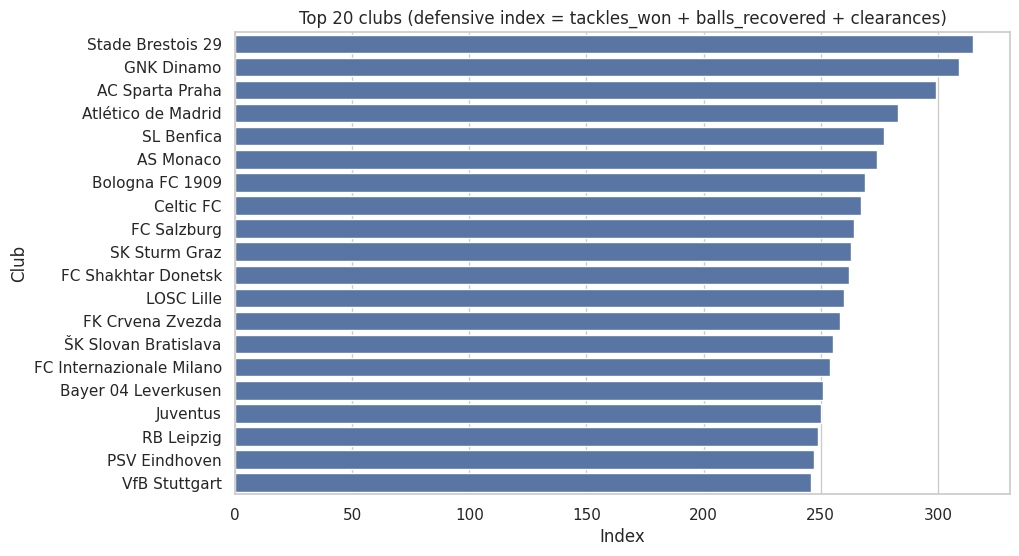

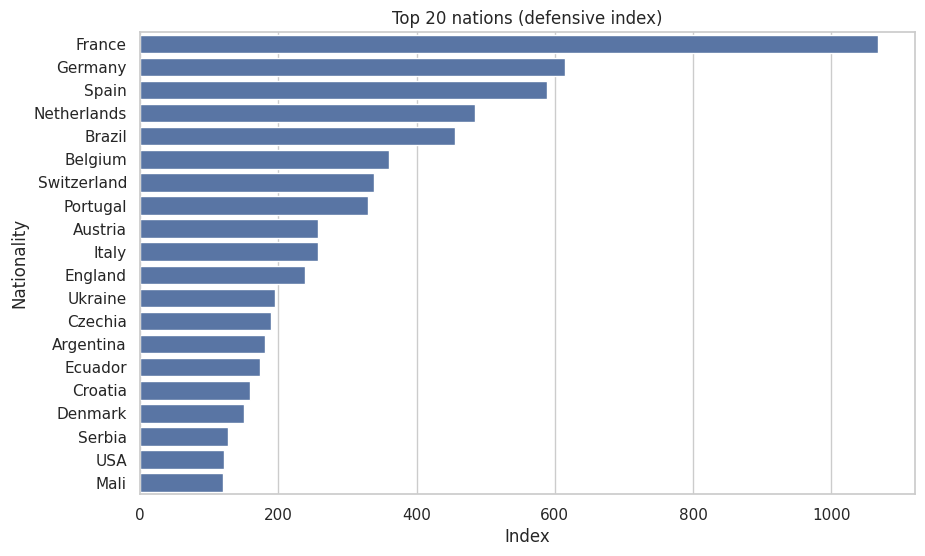

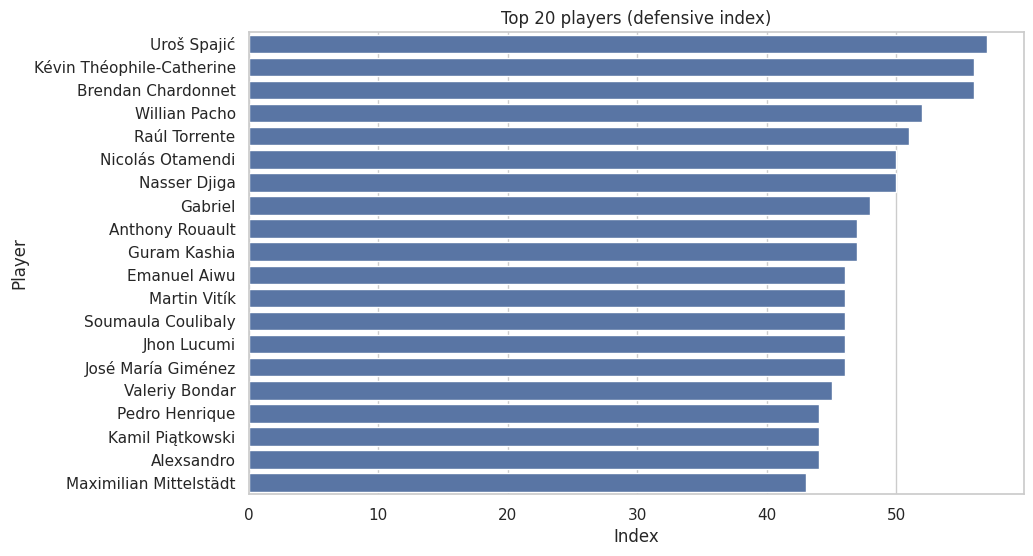

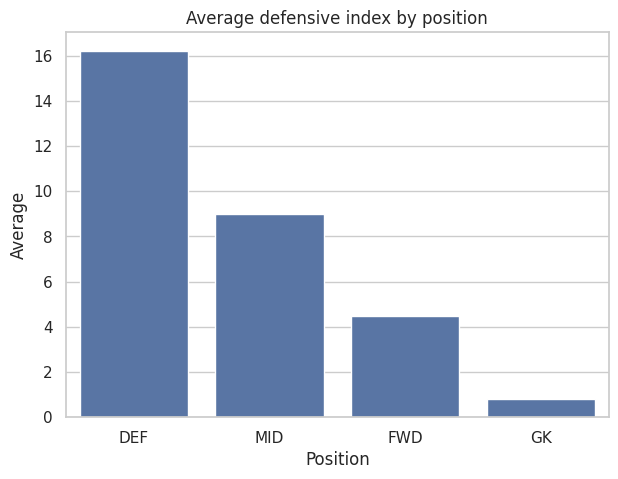

In [ ]:
DF_PID = coalesce_col(defending_data, ["id_player", "player_id", "id"])

defense = players_master[[P_ID, "player_name", "team", "league", "nationality", "pos_group"]].merge(
    defending_data, left_on=P_ID, right_on=DF_PID, how="left"
)

for c in ["balls_recovered","tackles","tackles_won","tackles_lost","clearance_attempted"]:
    if c in defense.columns:
        defense[c] = pd.to_numeric(defense[c], errors="coerce").fillna(0)

# By club (sum tackles_won + balls_recovered)
defense["def_index"] = defense.get("tackles_won", 0) + defense.get("balls_recovered", 0) + defense.get("clearance_attempted", 0)

d_by_team = defense.groupby("team")["def_index"].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=d_by_team.values, y=d_by_team.index)
plt.title("Top 20 clubs (defensive index = tackles_won + balls_recovered + clearances)")
plt.xlabel("Index")
plt.ylabel("Club")
plt.show()

# By nationality
d_by_nat = defense.groupby("nationality")["def_index"].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=d_by_nat.values, y=d_by_nat.index)
plt.title("Top 20 nations (defensive index)")
plt.xlabel("Index")
plt.ylabel("Nationality")
plt.show()

# By players
d_by_player = defense.groupby(["player_name","team"])["def_index"].sum().sort_values(ascending=False).head(20).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=d_by_player, x="def_index", y="player_name")
plt.title("Top 20 players (defensive index)")
plt.xlabel("Index")
plt.ylabel("Player")
plt.show()

# By position
d_by_pos = defense.groupby("pos_group")["def_index"].mean().sort_values(ascending=False)
plt.figure(figsize=(7,5))
sns.barplot(x=d_by_pos.index, y=d_by_pos.values)
plt.title("Average defensive index by position")
plt.xlabel("Position")
plt.ylabel("Average")
plt.show()


**Analiza golmana: obrambeni učinak i clean sheets**

U ovom dijelu analize fokus je isključivo na golmanima (GK) i njihovom obrambenom učinku. Podaci o golmanima izdvajaju se iz master tablice igrača te se spajaju s dostupnim golmanskim statistikama.

Postupak uključuje:

  * Filtriranje igrača na pozicijsku grupu GK

  * Spajanje s golmanskim skupom podataka pomoću ID-a igrača

  * Čišćenje i standardizaciju ključnih metrika (npr. obrane, primljeni golovi, clean sheets, obrane penala)

Nakon pripreme podataka provode se sljedeće analize:

1. Clean sheets po klubu
Agregiranjem podataka po klubu izračunava se ukupan broj clean sheets, a zatim se prikazuje Top 20 klubova s najviše utakmica bez primljenog gola. Ovaj prikaz daje uvid u kombinirani učinak golmana i obrambene strukture momčadi.

2. Individualna efikasnost golmana
Kao jednostavan proxy za učinak golmana koristi se omjer saves / goals conceded. Analiza je ograničena na golmane s minimalno 10 obrana kako bi se izbjegli ekstremi uzrokovani malim uzorkom. Rezultat ističe golmane koji bilježe velik broj obrana u odnosu na broj primljenih golova.

3. Clean sheets po nacionalnosti
Podaci se dodatno agregiraju po nacionalnosti kako bi se usporedio ukupan obrambeni učinak golmana iz različitih zemalja, ponovno koristeći clean sheets kao glavnu metriku.

Ova sekcija pruža pregled:

  * klupskog i individualnog doprinosa golmana obrambenoj stabilnosti,

  * razlika u profilu golmana između liga i nacionalnosti,

  * potencijalno podcijenjenih golmana s visokim učinkom u odnosu na broj primljenih golova.

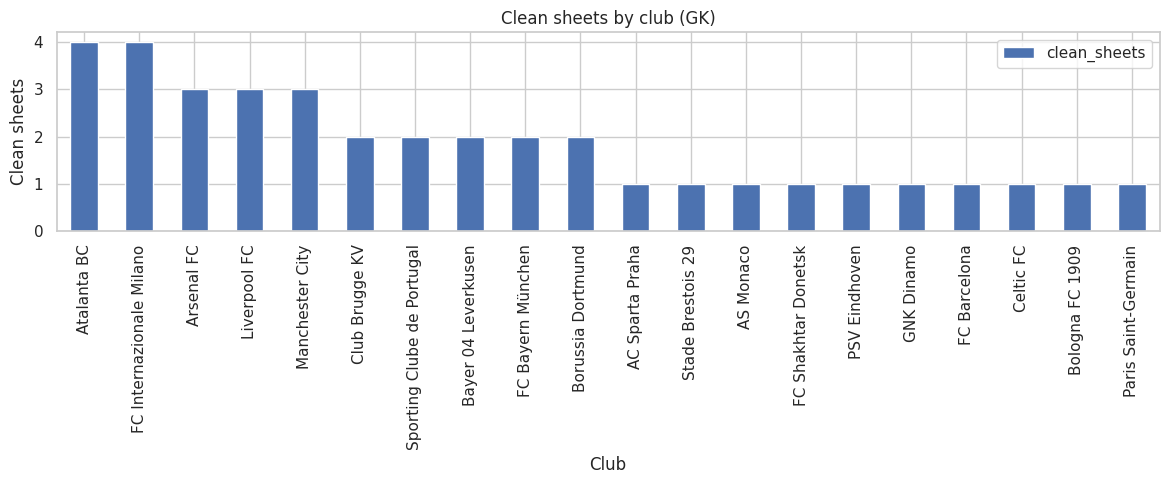

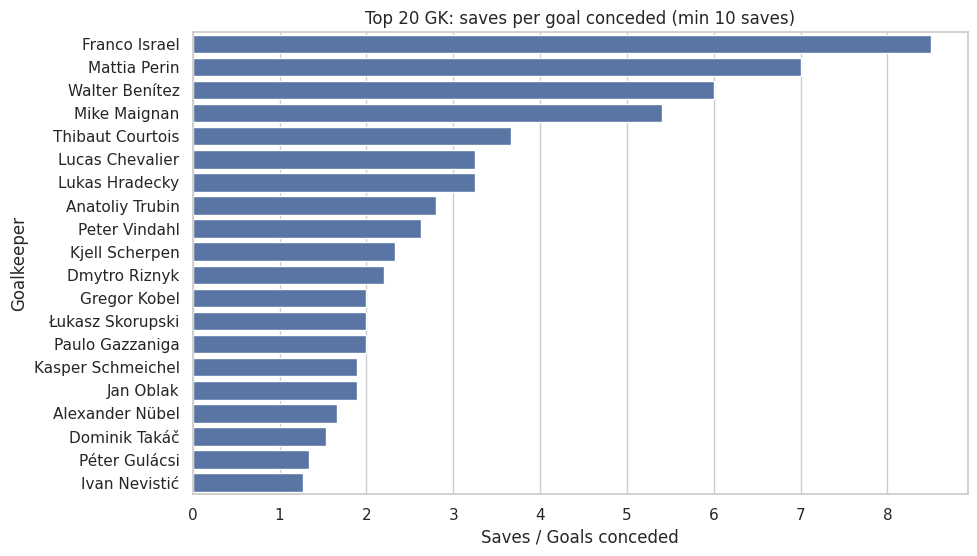

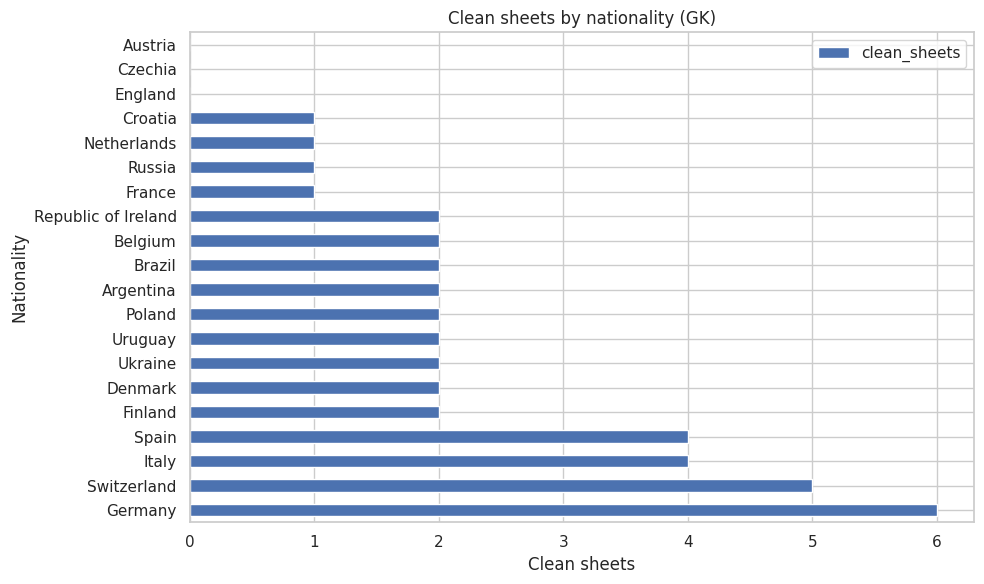

In [ ]:
GK_PID = coalesce_col(goalkeeping_data, ["id_player", "player_id", "id"])

gk = players_master[players_master["pos_group"]=="GK"][[P_ID, "player_name", "team", "league", "nationality"]].merge(
    goalkeeping_data, left_on=P_ID, right_on=GK_PID, how="left"
)

for c in ["saves","goals_conceded","saves_on_penalty","clean_sheets","punches_made"]:
    if c in gk.columns:
        gk[c] = pd.to_numeric(gk[c], errors="coerce").fillna(0)

# By club: saves, conceded, clean sheets
gk_team = gk.groupby("team")[["saves","goals_conceded","clean_sheets","saves_on_penalty"]].sum().sort_values("clean_sheets", ascending=False).head(20)

gk_team[["clean_sheets"]].plot(kind="bar", figsize=(12,5))
plt.title("Clean sheets by club (GK)")
plt.xlabel("Club")
plt.ylabel("Clean sheets")
plt.tight_layout()
plt.show()

# Goalkeeper performance proxy: saves per goal conceded (avoid div0)
gk["saves_per_conceded"] = np.where(gk["goals_conceded"] > 0, gk["saves"]/gk["goals_conceded"], np.nan)
top_gk = gk[gk["saves"] >= 10].sort_values("saves_per_conceded", ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(data=top_gk, x="saves_per_conceded", y="player_name")
plt.title("Top 20 GK: saves per goal conceded (min 10 saves)")
plt.xlabel("Saves / Goals conceded")
plt.ylabel("Goalkeeper")
plt.show()

# By nationality
gk_nat = gk.groupby("nationality")[["clean_sheets","saves","goals_conceded","saves_on_penalty"]].sum().sort_values("clean_sheets", ascending=False).head(20)
gk_nat[["clean_sheets"]].plot(kind="barh", figsize=(10,6))
plt.title("Clean sheets by nationality (GK)")
plt.xlabel("Clean sheets")
plt.ylabel("Nationality")
plt.tight_layout()
plt.show()


**Disciplina i prekršaji: kartoni, prekršaji napravljeni i pretrpljeni**

U ovom koraku analiziraju se disciplinarne statistike igrača (žuti/crveni kartoni) te prekršaji (pretrpljeni i napravljeni). Budući da se nazivi stupaca mogu razlikovati između izvora podataka, koristi se pomoćna funkcija coalesce_col() koja automatski pronalazi najvjerojatniji stupac za svaku metriku (npr. yellow, yellow_cards, yellows, itd.). Detektirani nazivi stupaca se ispisuju radi provjere.

Postupak obuhvaća:

  * Spajanje (merge) master tablice igrača s disciplinarnim podacima prema ID-u igrača

  * Automatsko prepoznavanje relevantnih stupaca za:

      * žute kartone

      * crvene kartone

      * prekršaje napravljene (committed)

      * prekršaje pretrpljene (suffered/drawn)

  * Čišćenje podataka (pretvaranje u numerički format i popunjavanje nedostajućih vrijednosti nulama)

Nakon pripreme podataka, generiraju se agregacije i vizualizacije:

  * Top 20 klubova prema ukupnom broju prekršaja/kartona (stupčasti graf)

  * Top 20 nacionalnosti prema ukupnom broju prekršaja/kartona (horizontalni stupčasti graf)

  * Prosječan broj žutih i crvenih kartona po pozicijskoj grupi (pos_group), kako bi se usporedile pozicijske razlike u disciplini

  * Ova analiza pomaže identificirati:

  * klubove i reprezentativne profile s izraženijim “agresivnim” stilom igre,

  * pozicije koje statistički češće ulaze u prekršaje i kartone, te odnose između “napravljenih” i “pretrpljenih” prekršaja (npr. ekipe/igrači koji više ruše vs. ekipe/igrači koji više iznuđuju prekršaje).

Detected: {'yellow': 'yellow_cards', 'red': 'red_cards', 'made': 'fouls_committed', 'suffered': 'fouls_suffered'}


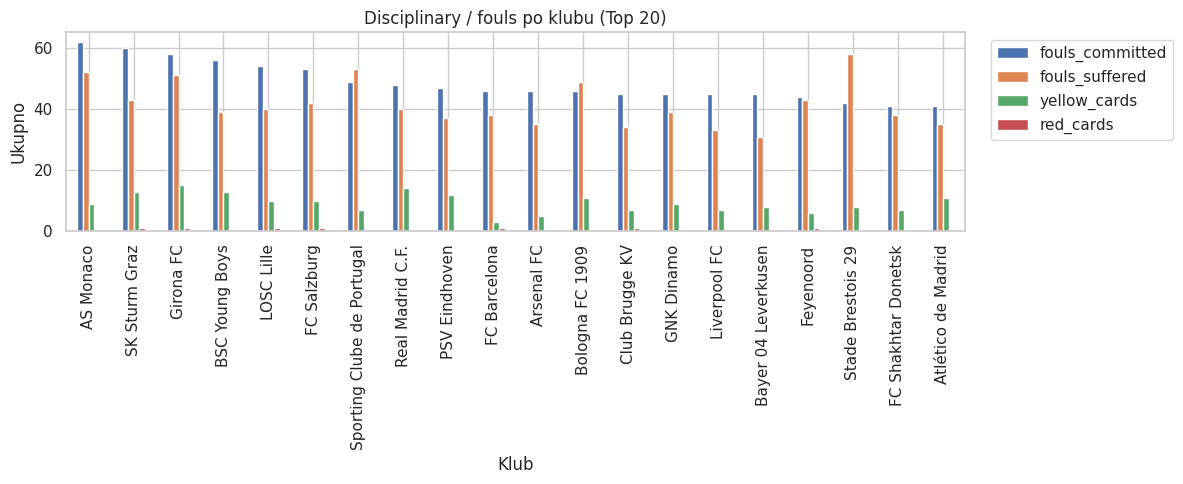

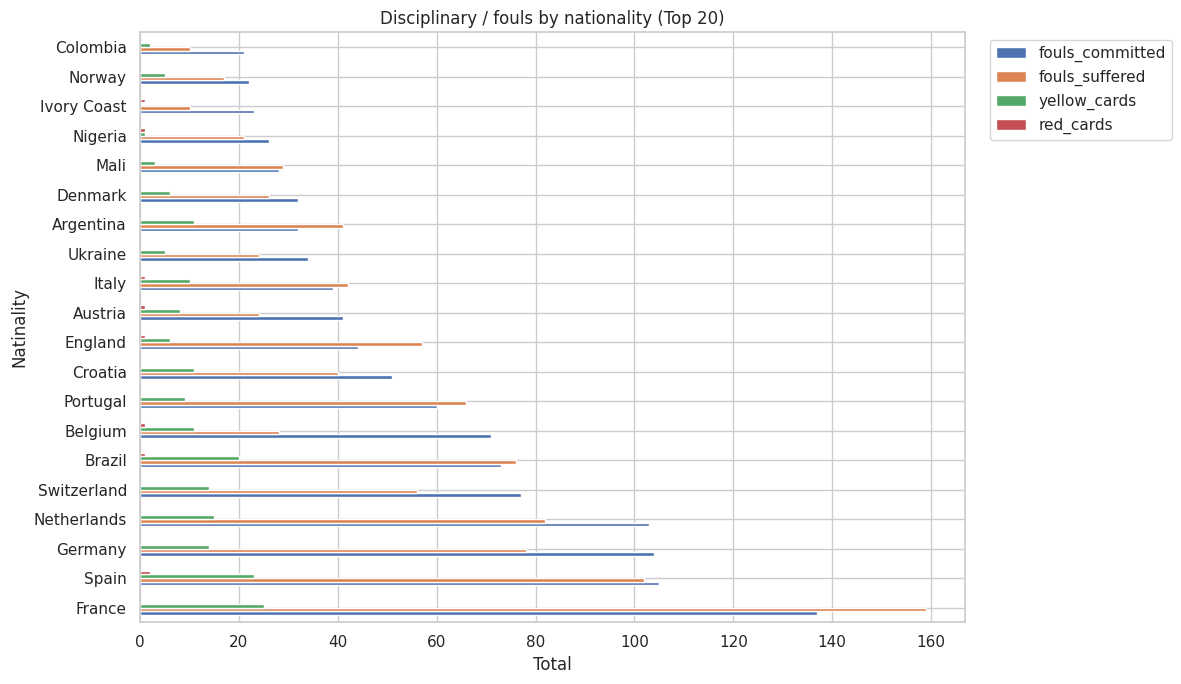

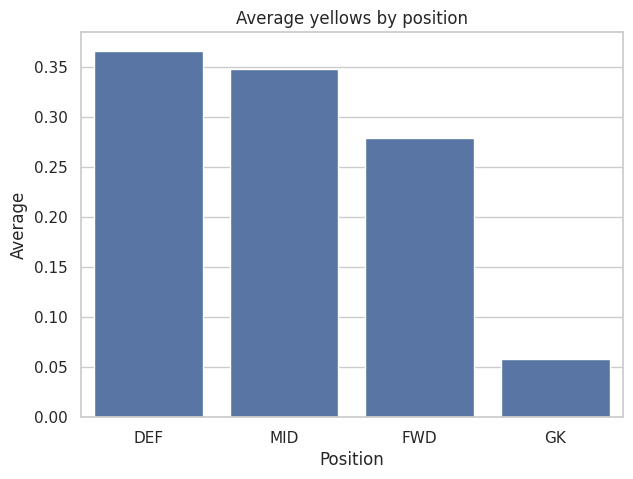

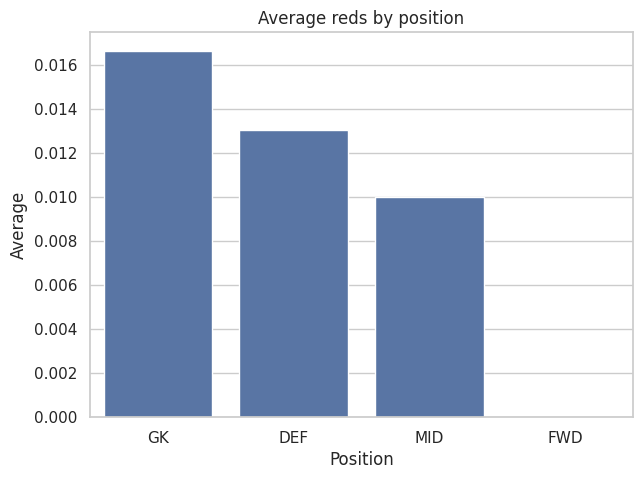

In [ ]:
DC_PID = coalesce_col(disciplinary_data, ["id_player", "player_id", "id"])

fouls = players_master[[P_ID, "player_name", "team", "league", "nationality", "pos_group"]].merge(
    disciplinary_data, left_on=P_ID, right_on=DC_PID, how="left"
)

# Try to find likely columns
col_yellow = coalesce_col(fouls, ["yellow", "yellow_cards", "yellows"])
col_red    = coalesce_col(fouls, ["red", "red_cards", "reds"])
col_fmade  = coalesce_col(fouls, ["fouls_committed", "fouls_made", "committed"])
col_fsuff  = coalesce_col(fouls, ["fouls_suffered", "fouls_drawn", "suffered", "drawn"])

for c in [col_yellow, col_red, col_fmade, col_fsuff]:
    if c and c in fouls.columns:
        fouls[c] = pd.to_numeric(fouls[c], errors="coerce").fillna(0)

print("Detected:", {"yellow": col_yellow, "red": col_red, "made": col_fmade, "suffered": col_fsuff})

# By club
agg_cols = [c for c in [col_fmade, col_fsuff, col_yellow, col_red] if c]
if agg_cols:
    by_team = fouls.groupby("team")[agg_cols].sum().sort_values(agg_cols[0], ascending=False).head(20)
    by_team.plot(kind="bar", figsize=(12,5))
    plt.title("Disciplinary / fouls po klubu (Top 20)")
    plt.xlabel("Klub")
    plt.ylabel("Ukupno")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # By nationality
    by_nat = fouls.groupby("nationality")[agg_cols].sum().sort_values(agg_cols[0], ascending=False).head(20)
    by_nat.plot(kind="barh", figsize=(12,7))
    plt.title("Disciplinary / fouls by nationality (Top 20)")
    plt.xlabel("Total")
    plt.ylabel("Natinality")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# By position: yellow/red
if col_yellow:
    pos_y = fouls.groupby("pos_group")[col_yellow].mean().sort_values(ascending=False)
    plt.figure(figsize=(7,5))
    sns.barplot(x=pos_y.index, y=pos_y.values)
    plt.title("Average yellows by position")
    plt.xlabel("Position")
    plt.ylabel("Average")
    plt.show()

if col_red:
    pos_r = fouls.groupby("pos_group")[col_red].mean().sort_values(ascending=False)
    plt.figure(figsize=(7,5))
    sns.barplot(x=pos_r.index, y=pos_r.values)
    plt.title("Average reds by position")
    plt.xlabel("Position")
    plt.ylabel("Average")
    plt.show()


**Efikasnost igrača po nacionalnosti i poziciji (GA / 90)**

U ovom dijelu analize ispituje se ofenzivna efikasnost igrača mjerena metrikom Goals + Assists per 90 minuts (GA/90), s ciljem usporedbe različitih nacionalnosti i pozicijskih grupa.

Postupak obuhvaća:

  * Spajanje podataka o odigranim minutama, golovima i asistencijama u jedinstvenu tablicu

  * Izračun ukupnog ofenzivnog doprinosa (Goals + Assists)

  * Normalizaciju učinka po 90 minuta igre radi usporedivosti između igrača

  * Filtriranje uzorka na igrače s minimalno 300 odigranih minuta kako bi se osigurala statistička relevantnost

  * Odabir 12 najzastupljenijih nacionalnosti u uzorku

  * Agregaciju podataka pomoću prosječne vrijednosti GA/90 po kombinaciji nacionalnost–pozicija

Rezultati su prikazani pomoću heatmap vizualizacije, koja omogućuje brz uvid u to:

  * koje nacionalnosti imaju najefikasnije igrače po pojedinim pozicijama

  * kako se ofenzivni doprinos razlikuje između obrambenih, veznih i napadačkih uloga

Ovakav prikaz posebno je koristan za skauting analize, usporedbu ligaških profila igrača te identifikaciju potencijalno podcijenjenih tržišta talenata.

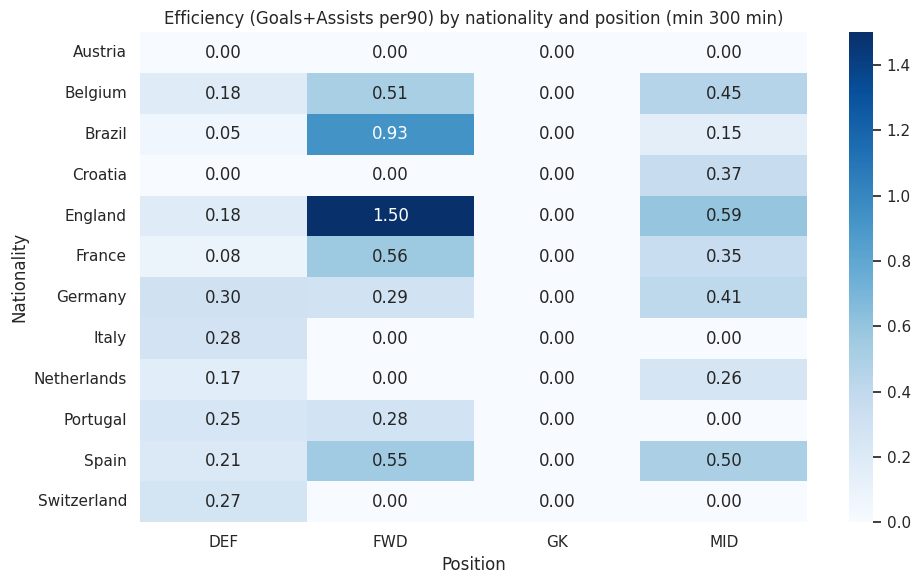

pos_group,DEF,FWD,GK,MID
nationality,,,,
Austria,0.00,0.00,0.0,0.00
Belgium,0.18,0.51,0.0,0.45
Brazil,0.05,0.93,0.0,0.15
Croatia,0.00,0.00,0.0,0.37
England,0.18,1.50,0.0,0.59
France,0.08,0.56,0.0,0.35
Germany,0.30,0.29,0.0,0.41
Italy,0.28,0.00,0.0,0.00
Netherlands,0.17,0.00,0.0,0.26


In [ ]:
# Merge minutes + goals + assists into one table
base = players_master[[P_ID, "player_name","team","league","nationality","pos_group"]].copy()

# minutes
if KS_PID:
    base = base.merge(key_stats_data[[KS_PID] + ([ "minutes_played" ] if "minutes_played" in key_stats_data.columns else [])],
                      left_on=P_ID, right_on=KS_PID, how="left")

# goals
if G_PID and "goals" in goals_data.columns:
    base = base.merge(goals_data[[G_PID, "goals"]], left_on=P_ID, right_on=G_PID, how="left")

# assists
if AT_PID and "assists" in attacking_data.columns:
    base = base.merge(attacking_data[[AT_PID, "assists"]], left_on=P_ID, right_on=AT_PID, how="left")

for c in ["minutes_played","goals","assists"]:
    if c in base.columns:
        base[c] = pd.to_numeric(base[c], errors="coerce").fillna(0)

# per 90
base["g_a"] = base.get("goals", 0) + base.get("assists", 0)
base["per90"] = np.where(base["minutes_played"] > 0, base["g_a"] / base["minutes_played"] * 90, np.nan)

# focus on meaningful sample
top_nat = base["nationality"].value_counts().head(12).index
tmp = base[base["nationality"].isin(top_nat) & (base["minutes_played"] >= 300)]

pivot = tmp.pivot_table(index="nationality", columns="pos_group", values="per90", aggfunc="mean").fillna(0)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Blues")
plt.title("Efficiency (Goals+Assists per90) by nationality and position (min 300 min)")
plt.xlabel("Position")
plt.ylabel("Nationality")
plt.tight_layout()
plt.show()

pivot.round(2)


**Distribucija golova po ligama**

U ovom koraku analizira se ukupan broj postignutih golova po ligama, na temelju podataka o golovima igrača. Podaci se agregiraju grupiranjem prema varijabli league, pri čemu liga predstavlja natjecanje u kojem igrač nastupa (uz fallback na državu kluba u slučajevima kada liga nije eksplicitno definirana).

Postupak uključuje:

  * Grupiranje podataka po ligi

  * Zbrajanje ukupnog broja golova unutar svake lige

  * Sortiranje liga prema ukupnom broju golova (silazno)

  * Izdvajanje top 20 liga s najvećim brojem golova

  * Vizualizaciju rezultata pomoću horizontalnog stupčastog grafikona

Grafikon omogućuje brzu usporedbu liga prema ofenzivnoj produkciji te jasno ističe lige s najvećim doprinosom ukupnom broju golova u promatranom uzorku podataka.

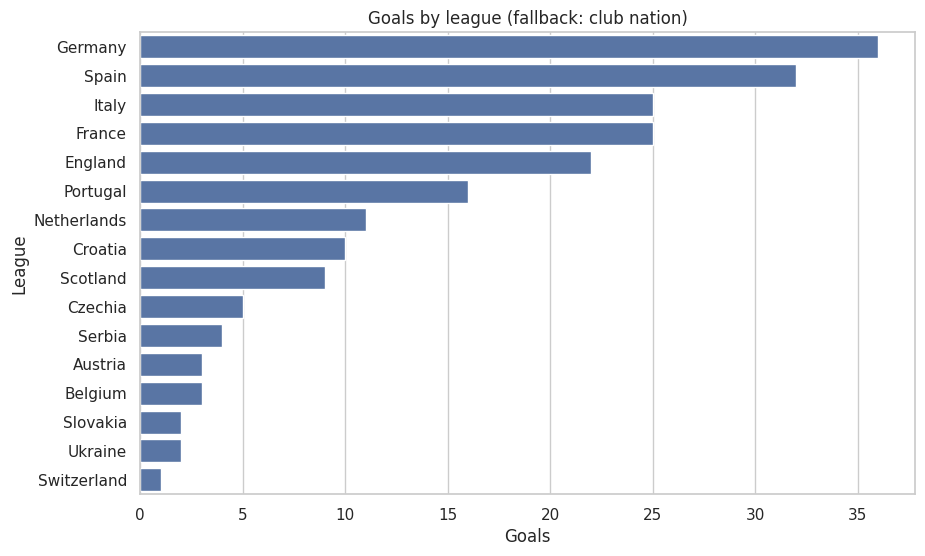

,goals
league,
Germany,36.0
Spain,32.0
Italy,25.0
France,25.0
England,22.0
Portugal,16.0
Netherlands,11.0
Croatia,10.0
Scotland,9.0


In [ ]:
g_league = scoring.groupby("league")["goals"].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=g_league.values, y=g_league.index)
plt.title("Goals by league (fallback: club nation)")
plt.xlabel("Goals")
plt.ylabel("League")
plt.show()

g_league


**Obrada i rangiranje igrača prema golovima i asistencijama (GA / 90)**

U ovom koraku izrađuje se objedinjena tablica ofenzivnog učinka igrača kombiniranjem podataka o golovima, asistencijama i odigranim minutama iz različitih izvora podataka.

Postupak uključuje:

  * Kopiranje osnovne tablice s podacima o postignutim golovima

  * Spajanje asistencija iz attacking skupa podataka (ako su dostupne)

  * Spajanje informacija o minutama igranja iz key stats skupa podataka

  * Čišćenje numeričkih vrijednosti i popunjavanje nedostajućih podataka nulama

  * Izračun ukupnog učinka GA (Goals + Assists)

  * Normalizaciju učinka po 90 minuta igre (GA per 90)

Na kraju se igrači rangiraju prema GA per 90, uz dodatni kriterij ukupnog GA, te se izdvaja top 25 igrača s najefikasnijim ofenzivnim učinkom, zajedno s osnovnim kontekstualnim informacijama (klub, liga, pozicija, nacionalnost).

In [ ]:
summary = scoring.copy()

# Add assists if present
if "assists" in attacking_data.columns:
    summary = summary.merge(attacking_data[[AT_PID, "assists"]], left_on=P_ID, right_on=AT_PID, how="left")
summary["assists"] = pd.to_numeric(summary.get("assists", 0), errors="coerce").fillna(0)

# Add minutes if present
if "minutes_played" in key_stats_data.columns:
    summary = summary.merge(key_stats_data[[KS_PID, "minutes_played"]], left_on=P_ID, right_on=KS_PID, how="left")
summary["minutes_played"] = pd.to_numeric(summary.get("minutes_played", 0), errors="coerce").fillna(0)

summary["ga"] = summary.get("goals", 0) + summary.get("assists", 0)
summary["ga_per90"] = np.where(summary["minutes_played"] > 0, summary["ga"]/summary["minutes_played"]*90, np.nan)

top_table = summary.sort_values(["ga_per90","ga"], ascending=False).head(25)[
    ["player_name","team","league","nationality","pos_group","minutes_played","goals","assists","ga","ga_per90"]
]
top_table


,player_name,team,league,nationality,pos_group,minutes_played,goals,assists,ga,ga_per90
670,Daouda Guindo,FC Salzburg,Austria,Mali,DEF,18.0,1.0,0.0,1.0,5.000000
605,Felício Milson,FK Crvena Zvezda,Serbia,Angola,MID,50.0,2.0,0.0,2.0,3.600000
648,James Forrest,Celtic FC,Scotland,Scotland,MID,28.0,0.0,1.0,1.0,3.214286
520,Fermín López,FC Barcelona,Spain,Spain,FWD,93.0,1.0,2.0,3.0,2.903226
643,Lukáš Sadílek,AC Sparta Praha,Czechia,Czechia,MID,31.0,0.0,1.0,1.0,2.903226
632,Mathias Pereira Lage,Stade Brestois 29,France,France,FWD,38.0,1.0,0.0,1.0,2.368421
155,Raphinha,FC Barcelona,Spain,Brazil,FWD,314.0,5.0,3.0,8.0,2.292994
561,Nicolás González,Juventus,Italy,Argentina,FWD,81.0,1.0,1.0,2.0,2.222222
625,Samuel Chukwueze,AC Milan,Italy,Nigeria,FWD,41.0,0.0,1.0,1.0,2.195122
622,Leon Goretzka,FC Bayern München,Germany,Germany,MID,43.0,1.0,0.0,1.0,2.093023


# Task
Calculate the composite strength index for each club by aggregating performance metrics (goals, assists, defensive index, clean sheets), normalizing them, and then visualizing the top 20 clubs based on this score, summarizing the findings to identify the strongest clubs and interpret their potential chances of winning.

## Calculate Composite Strength Index

### Subtask:
Execute the code cell that aggregates various performance metrics (goals, assists, defensive index, clean sheets), normalizes them, and calculates a composite 'overall_strength_score' for each club.


**Reasoning**:
The subtask requires executing the code cell that calculates the composite strength index for clubs. This specific code cell `fc17799e` performs all the necessary steps, including aggregation, normalization, and calculation of the composite score.



**Reasoning**:
The previous code failed because several essential dataframes (`players_master`, `summary`, `defense`, `gk`) were not defined. To fix this, I will create a new code block that executes all the preceding setup cells responsible for loading data, cleaning, merging, and creating these required dataframes. This ensures all dependencies are met before attempting to calculate the composite strength index.



In [ ]:
# ====== Imports ======
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Optional (nice looking charts). If not installed, comment it out.
import seaborn as sns
sns.set_theme(style="whitegrid")

# For display options
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

# ====== Load CSVs ======
# If files are in Colab environment (uploaded or mounted Drive), change the paths accordingly.
attacking_data     = pd.read_csv('/kaggle/attacking_data.csv')
attempts_data      = pd.read_csv('/kaggle/attempts_data.csv')
disciplinary_data  = pd.read_csv('/kaggle/disciplinary_data.csv')
defending_data     = pd.read_csv('/kaggle/defending_data.csv')
distribution_data  = pd.read_csv('/kaggle/distribution_data.csv')
goals_data         = pd.read_csv('/kaggle/goals_data.csv')
goalkeeping_data   = pd.read_csv('/kaggle/goalkeeping_data.csv')
key_stats_data     = pd.read_csv('/kaggle/key_stats_data.csv')
players_data       = pd.read_csv('/kaggle/players_data.csv')
teams_data         = pd.read_csv('/kaggle/teams_data.csv')

def normalize_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    return df

attacking_data    = normalize_cols(attacking_data)
attempts_data     = normalize_cols(attempts_data)
disciplinary_data = normalize_cols(disciplinary_data)
defending_data    = normalize_cols(defending_data)
distribution_data = normalize_cols(distribution_data)
goals_data        = normalize_cols(goals_data)
goalkeeping_data  = normalize_cols(goalkeeping_data)
key_stats_data    = normalize_cols(key_stats_data)
players_data      = normalize_cols(players_data)
teams_data        = normalize_cols(teams_data)

def coalesce_col(df, candidates):
    """Return first matching column name from candidates list (case already normalized)."""
    for c in candidates:
        if c in df.columns:
            return c
    return None

# Key columns
P_ID = coalesce_col(players_data, ["id_player", "player_id", "id"])
T_ID_PLAYERS = coalesce_col(players_data, ["id_team", "team_id"])
T_ID_TEAMS = coalesce_col(teams_data, ["team_id", "id_team", "id"])

TEAM_NAME = coalesce_col(teams_data, ["team", "team_name", "club"])
TEAM_COUNTRY = coalesce_col(teams_data, ["country", "team_country", "nation"])
LEAGUE_COL = coalesce_col(teams_data, ["league", "competition", "domestic_league"])

# Create players + teams master
players_master = players_data.merge(
    teams_data[[T_ID_TEAMS, TEAM_NAME, TEAM_COUNTRY] + ([LEAGUE_COL] if LEAGUE_COL else [])],
    left_on=T_ID_PLAYERS,
    right_on=T_ID_TEAMS,
    how="left"
)

# Standardize some key labels
players_master = players_master.rename(columns={
    "player_name": "player_name",
    "nationality": "nationality",
    "position": "position",
    "field_position": "field_position",
    TEAM_NAME: "team",
    TEAM_COUNTRY: "team_country",
    (LEAGUE_COL if LEAGUE_COL else "___"): "league"
})

# If league doesn't exist, fallback to team_country as a proxy
if "league" not in players_master.columns or players_master["league"].isna().all():
    players_master["league"] = players_master.get("team_country", np.nan)

# Pick best position column available
pos_col = "field_position" if "field_position" in players_master.columns else "position"

# Create broader position group (GK/DEF/MID/FWD)
def map_pos(p):
    if pd.isna(p): return np.nan
    p = str(p).lower()
    if "goal" in p or p in ["gk", "goalkeeper"]:
        return "GK"
    if any(x in p for x in ["def", "back", "cb", "lb", "rb", "wing-back"]):
        return "DEF"
    if any(x in p for x in ["mid", "cm", "dm", "am", "wing", "rm", "lm"]):
        return "MID"
    if any(x in p for x in ["for", "str", "fw", "att", "st", "cf"]):
        return "FWD"
    return "OTHER"

players_master["pos_group"] = players_master[pos_col].apply(map_pos)

# Numeric cleaning
for c in ["age", "height(cm)", "weight(kg)"]:
    if c in players_master.columns:
        players_master[c] = pd.to_numeric(players_master[c], errors="coerce")

# Definition of various PIDs for merging later
G_PID = coalesce_col(goals_data, ["id_player", "player_id", "id"])
A_PID = coalesce_col(attempts_data, ["id_player", "player_id", "id"])
AT_PID = coalesce_col(attacking_data, ["id_player", "player_id", "id"])
KS_PID = coalesce_col(key_stats_data, ["id_player", "player_id", "id"])
D_PID = coalesce_col(distribution_data, ["id_player", "player_id", "id"])
DF_PID = coalesce_col(defending_data, ["id_player", "player_id", "id"])
GK_PID = coalesce_col(goalkeeping_data, ["id_player", "player_id", "id"])
DC_PID = coalesce_col(disciplinary_data, ["id_player", "player_id", "id"])

# Create 'scoring' dataframe (from cell 6bHuDU4ZEtKn)
scoring = players_master[[P_ID, "player_name", "team", "league", "nationality", "pos_group"]].copy()
if G_PID:
    scoring = scoring.merge(goals_data, left_on=P_ID, right_on=G_PID, how="left", suffixes=("", "_goals"))
if A_PID:
    scoring = scoring.merge(attempts_data, left_on=P_ID, right_on=A_PID, how="left", suffixes=("", "_att"))
num_cols_scoring = [
    "goals","inside_area","outside_area","right_foot","left_foot","head","other","penalties_scored",
    "total_attempts","attempts_on_target","attempts_off_target","blocked"
]
for c in num_cols_scoring:
    if c in scoring.columns:
        scoring[c] = pd.to_numeric(scoring[c], errors="coerce").fillna(0)

# Create 'summary' dataframe (from cell dQizfL62FlVw)
summary = scoring.copy()
if "assists" in attacking_data.columns:
    summary = summary.merge(attacking_data[[AT_PID, "assists"]], left_on=P_ID, right_on=AT_PID, how="left")
summary["assists"] = pd.to_numeric(summary.get("assists", 0), errors="coerce").fillna(0)
if "minutes_played" in key_stats_data.columns:
    summary = summary.merge(key_stats_data[[KS_PID, "minutes_played"]], left_on=P_ID, right_on=KS_PID, how="left")
summary["minutes_played"] = pd.to_numeric(summary.get("minutes_played", 0), errors="coerce").fillna(0)
summary["ga"] = summary.get("goals", 0) + summary.get("assists", 0)
summary["ga_per90"] = np.where(summary["minutes_played"] > 0, summary["ga"]/summary["minutes_played"]*90, np.nan)

# Create 'defense' dataframe (from cell GKjvAGSDFUkP)
defense = players_master[[P_ID, "player_name", "team", "league", "nationality", "pos_group"]].merge(
    defending_data, left_on=P_ID, right_on=DF_PID, how="left"
)
for c in ["balls_recovered","tackles","tackles_won","tackles_lost","clearance_attempted"]:
    if c in defense.columns:
        defense[c] = pd.to_numeric(defense[c], errors="coerce").fillna(0)
defense["def_index"] = defense.get("tackles_won", 0) + defense.get("balls_recovered", 0) + defense.get("clearance_attempted", 0)

# Create 'gk' dataframe (from cell CODwt5IDFXa5)
gk = players_master[players_master["pos_group"]=="GK"][[P_ID, "player_name", "team", "league", "nationality"]].merge(
    goalkeeping_data, left_on=P_ID, right_on=GK_PID, how="left"
)
for c in ["saves","goals_conceded","saves_on_penalty","clean_sheets","punches_made"]:
    if c in gk.columns:
        gk[c] = pd.to_numeric(gk[c], errors="coerce").fillna(0)


Results columns fixed: ['matchday', 'home_team', 'away_team', 'winner']

Top 20 Clubs (Difficulty Adjusted, Wins + UEFA Coeff):

                          team  overall_strength_score  scaled_difficulty  adjusted_strength_score
9            Borussia Dortmund               71.578938           0.363375                84.583947
13           FC Bayern München               53.554212           0.744483                73.489312
2                    AS Monaco               66.164469           0.217455                73.358374
12                FC Barcelona               59.620513           0.354692                70.193972
31  Sporting Clube de Portugal               62.558791           0.183565                68.300602
32           Stade Brestois 29               63.085714           0.094803                66.076058
28            Real Madrid C.F.               47.780220           0.635131                62.953567
10                   Celtic FC               50.463919           0.323155      

/tmp/ipython-input-271836221.py:136: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  club_strength["uefa_coeff"] = club_strength["uefa_coeff"].fillna(0)
/tmp/ipython-input-271836221.py:187: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20, x="adjusted_strength_score", y="team", palette="magma")


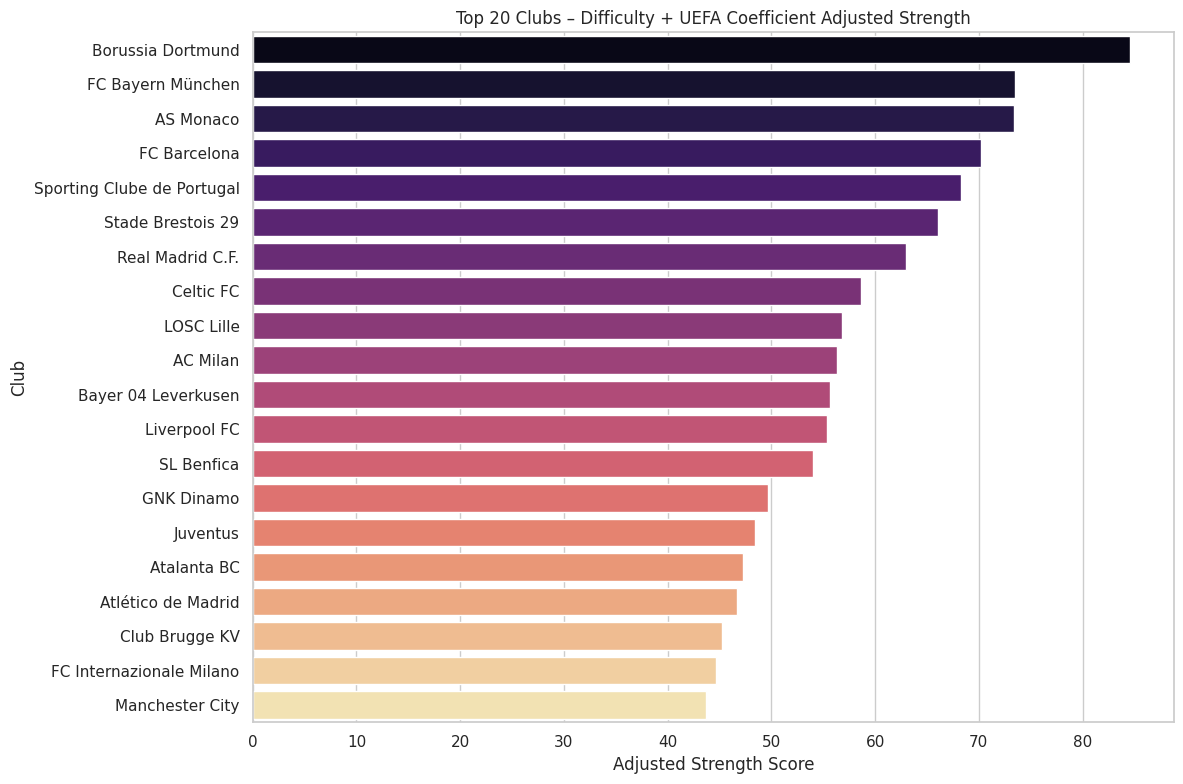

In [ ]:
# =========================
# Imports
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

# =========================
# Utility Functions
# =========================
def normalize_cols(df):
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    return df

def coalesce_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def map_pos(p):
    if pd.isna(p): return np.nan
    p = str(p).lower()
    if "goal" in p or p in ["gk", "goalkeeper"]: return "GK"
    if any(x in p for x in ["def", "back", "cb", "lb", "rb", "wing-back"]): return "DEF"
    if any(x in p for x in ["mid", "cm", "dm", "am", "wing", "rm", "lm"]): return "MID"
    if any(x in p for x in ["for", "str", "fw", "att", "st", "cf"]): return "FWD"
    return "OTHER"

# =========================
# Load Kaggle CSVs
# =========================
attacking_data     = normalize_cols(pd.read_csv('/kaggle/attacking_data.csv'))
attempts_data      = normalize_cols(pd.read_csv('/kaggle/attempts_data.csv'))
disciplinary_data  = normalize_cols(pd.read_csv('/kaggle/disciplinary_data.csv'))
defending_data     = normalize_cols(pd.read_csv('/kaggle/defending_data.csv'))
distribution_data  = normalize_cols(pd.read_csv('/kaggle/distribution_data.csv'))
goals_data         = normalize_cols(pd.read_csv('/kaggle/goals_data.csv'))
goalkeeping_data   = normalize_cols(pd.read_csv('/kaggle/goalkeeping_data.csv'))
key_stats_data     = normalize_cols(pd.read_csv('/kaggle/key_stats_data.csv'))
players_data       = normalize_cols(pd.read_csv('/kaggle/players_data.csv'))
teams_data         = normalize_cols(pd.read_csv('/kaggle/teams_data.csv'))

# =========================
# Load Results.xlsx
# =========================
results = pd.read_excel('/kaggle/Results.xlsx')
if len(results.columns) == 1 and ',' in results.columns[0]:
    results = results[results.columns[0]].str.split(',', expand=True)
    results.columns = ['matchday', 'home_team', 'away_team', 'winner']
results.columns = [c.strip().lower() for c in results.columns]
results['winner'] = results['winner'].str.strip()
print("Results columns fixed:", results.columns.tolist())

# =========================
# IDs and Columns
# =========================
P_ID = coalesce_col(players_data, ["id_player", "player_id", "id"])
T_ID_PLAYERS = coalesce_col(players_data, ["id_team", "team_id"])
T_ID_TEAMS = coalesce_col(teams_data, ["team_id", "id_team", "id"])
TEAM_NAME = coalesce_col(teams_data, ["team", "team_name", "club"])
TEAM_COUNTRY = coalesce_col(teams_data, ["country", "team_country"])

# =========================
# Players Master Table
# =========================
players_master = players_data.merge(
    teams_data[[T_ID_TEAMS, TEAM_NAME, TEAM_COUNTRY]],
    left_on=T_ID_PLAYERS, right_on=T_ID_TEAMS,
    how="left"
).rename(columns={TEAM_NAME: "team", TEAM_COUNTRY: "team_country"})
players_master["pos_group"] = players_master[
    "field_position" if "field_position" in players_master.columns else "position"
].apply(map_pos)

# =========================
# Scoring Summary
# =========================
summary = players_master[[P_ID, "player_name", "team", "pos_group"]].copy()
summary = summary.merge(goals_data, left_on=P_ID, right_on=coalesce_col(goals_data,[P_ID]), how="left")
summary = summary.merge(attacking_data[[coalesce_col(attacking_data,[P_ID]), "assists"]],
                        left_on=P_ID, right_on=coalesce_col(attacking_data,[P_ID]), how="left")
summary = summary.merge(key_stats_data[[coalesce_col(key_stats_data,[P_ID]), "minutes_played"]],
                        left_on=P_ID, right_on=coalesce_col(key_stats_data,[P_ID]), how="left")
for c in ["goals", "assists", "minutes_played"]:
    summary[c] = pd.to_numeric(summary.get(c, 0), errors="coerce").fillna(0)

# =========================
# Defense
# =========================
defense = players_master[[P_ID, "team"]].merge(
    defending_data, left_on=P_ID, right_on=coalesce_col(defending_data,[P_ID]), how="left"
)
for c in ["tackles_won", "balls_recovered", "clearance_attempted"]:
    defense[c] = pd.to_numeric(defense.get(c, 0), errors="coerce").fillna(0)
defense["def_index"] = defense["tackles_won"] + defense["balls_recovered"] + defense["clearance_attempted"]

# =========================
# Goalkeeping
# =========================
gk = players_master[players_master["pos_group"] == "GK"][[P_ID, "team"]].merge(
    goalkeeping_data, left_on=P_ID, right_on=coalesce_col(goalkeeping_data,[P_ID]), how="left"
)
gk["clean_sheets"] = pd.to_numeric(gk.get("clean_sheets", 0), errors="coerce").fillna(0)

# =========================
# Club Strength (Baseline)
# =========================
club_strength = summary.groupby("team").agg(
    total_goals=("goals","sum"),
    total_assists=("assists","sum")
).reset_index()
club_strength = club_strength.merge(defense.groupby("team")["def_index"].sum().reset_index(), on="team", how="left")
club_strength = club_strength.merge(gk.groupby("team")["clean_sheets"].sum().reset_index(), on="team", how="left").fillna(0)

# =========================
# Wins (most important historical metric)
# =========================
wins = results[results['winner'] != 'Draw'].groupby('winner').size().reset_index(name='wins')
wins = wins.rename(columns={'winner':'team'})
club_strength = club_strength.merge(wins, on='team', how='left')
club_strength['wins'] = club_strength['wins'].fillna(0)

# =========================
# Load UEFA Coefficients
# =========================
coeff_df = pd.read_csv("/kaggle/coefficients.txt", header=None, names=["team","uefa_coeff"])
coeff_df["team"] = coeff_df["team"].str.strip()
club_strength = club_strength.merge(coeff_df, on="team", how="left")
club_strength["uefa_coeff"] = club_strength["uefa_coeff"].fillna(0)

# =========================
# Scaling Metrics
# =========================
metrics = ['wins', 'total_goals', 'total_assists', 'def_index', 'clean_sheets', 'uefa_coeff']
scaler = MinMaxScaler()
club_strength[[f"s_{m}" for m in metrics]] = scaler.fit_transform(club_strength[metrics])

# =========================
# Weighted Overall Strength Score
# =========================
club_strength["overall_strength_score"] = (
    40 * club_strength['s_wins'] +
    30* club_strength['s_total_goals'] +
    1.5 * club_strength['s_total_assists'] +
    5 * club_strength['s_def_index'] +
    1.2 * club_strength['s_clean_sheets'] +
    50 * club_strength['s_uefa_coeff']
)

# =========================
# Strength of Schedule (Difficulty)
# =========================
strength_map = club_strength.set_index("team")["overall_strength_score"]
results["home_opp"] = results["away_team"].map(strength_map)
results["away_opp"] = results["home_team"].map(strength_map)
schedule = pd.concat([
    results[["home_team","home_opp"]].rename(columns={"home_team":"team","home_opp":"opp_strength"}),
    results[["away_team","away_opp"]].rename(columns={"away_team":"team","away_opp":"opp_strength"})
])
schedule = schedule.groupby("team")["opp_strength"].mean().reset_index()
schedule["scaled_difficulty"] = MinMaxScaler().fit_transform(schedule[["opp_strength"]])
club_strength = club_strength.merge(schedule, on="team", how="left")
club_strength["scaled_difficulty"] = club_strength["scaled_difficulty"].fillna(club_strength["scaled_difficulty"].mean())

# =========================
# Difficulty-Adjusted Score
# =========================
club_strength["adjusted_strength_score"] = (
    club_strength["overall_strength_score"] * (1 + 0.5 * club_strength["scaled_difficulty"])
)

# =========================
# Final Ranking
# =========================
top20 = club_strength.sort_values("adjusted_strength_score", ascending=False).head(20)
print("\nTop 20 Clubs (Difficulty Adjusted, Wins + UEFA Coeff):\n")
print(top20[["team","overall_strength_score","scaled_difficulty","adjusted_strength_score"]])

plt.figure(figsize=(12,8))
sns.barplot(data=top20, x="adjusted_strength_score", y="team", palette="magma")
plt.title("Top 20 Clubs – Difficulty + UEFA Coefficient Adjusted Strength")
plt.xlabel("Adjusted Strength Score")
plt.ylabel("Club")
plt.tight_layout()
plt.show()


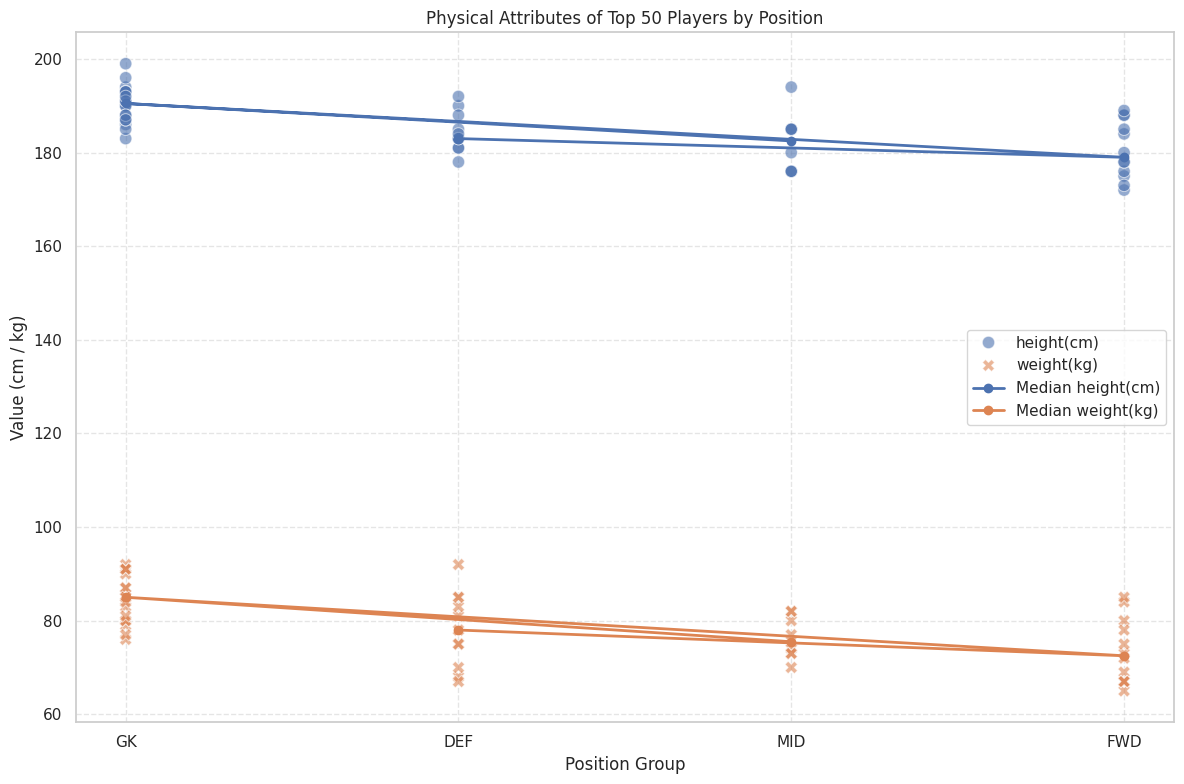

Summary of top 50 players' physique by position:
          height(cm)        weight(kg)       
                mean median       mean median
pos_group                                    
DEF            184.4  183.0       78.1   78.0
FWD            180.5  179.0       73.5   72.5
GK             190.3  190.5       84.7   85.0
MID            182.1  182.5       76.4   75.5


In [ ]:
# =========================
# Top 50 Players by Position Physique
# =========================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ensure numeric columns exist safely
for col in ['goals', 'assists', 'clean_sheets']:
    if col in players_master.columns:
        players_master[col] = pd.to_numeric(players_master[col], errors='coerce').fillna(0)
    else:
        players_master[col] = 0

# Compute offensive score for outfield players
players_master['offensive_score'] = players_master['goals'] + players_master['assists']

# Initialize empty list to collect top players
top_players_list = []

# Top 50 GKs by clean_sheets
gk_top = players_master[players_master['pos_group']=='GK'].sort_values('clean_sheets', ascending=False).head(50)
top_players_list.append(gk_top)

# Top 50 DEF/MID/FWD by offensive_score per position
for pos in ['DEF','MID','FWD']:
    pos_top = players_master[players_master['pos_group']==pos].sort_values('offensive_score', ascending=False).head(50)
    top_players_list.append(pos_top)

# Combine
top_players = pd.concat(top_players_list)

# Filter out players without height or weight
top_players = top_players[top_players['height(cm)'].notna() & top_players['weight(kg)'].notna()]

# Optional: convert height to meters
top_players['height_m'] = top_players['height(cm)'] / 100

# Melt for plotting
physique_melted = top_players.melt(
    id_vars=['pos_group','player_name'],
    value_vars=['height(cm)','weight(kg)'],
    var_name='attribute',
    value_name='value'
)

# Plot scatter with median line per position
plt.figure(figsize=(12,8))
sns.scatterplot(
    data=physique_melted,
    x='pos_group',
    y='value',
    hue='attribute',
    style='attribute',
    alpha=0.6,
    s=80
)

# Compute median per position & attribute
medians = physique_melted.groupby(['pos_group','attribute'])['value'].median().reset_index()

# Plot median lines
for attr in ['height(cm)','weight(kg)']:
    subset = medians[medians['attribute']==attr]
    plt.plot(subset['pos_group'], subset['value'], marker='o', linewidth=2, label=f'Median {attr}')

plt.title('Physical Attributes of Top 50 Players by Position')
plt.xlabel('Position Group')
plt.ylabel('Value (cm / kg)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Summary table for top 50 players
summary_stats = top_players.groupby('pos_group')[['height(cm)','weight(kg)']].agg(['mean','median']).round(1)
print("Summary of top 50 players' physique by position:")
print(summary_stats)


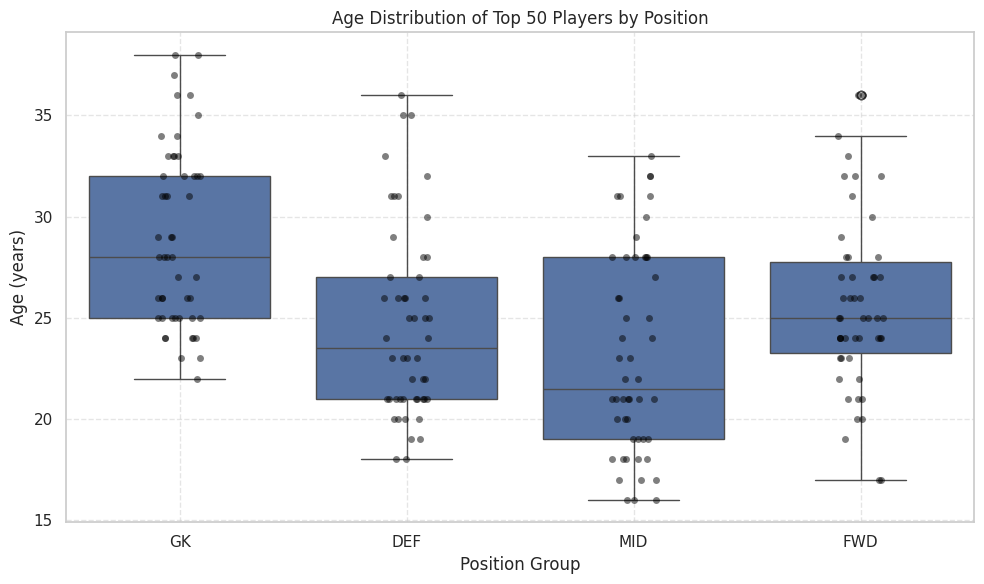

Summary of age for top 50 players by position:
           mean  median  min  max
pos_group                        
DEF        24.7    23.5   18   36
FWD        25.7    25.0   17   36
GK         29.0    28.0   22   38
MID        23.1    21.5   16   33


In [ ]:
# =========================
# Top 50 Players by Position (Age Only)
# =========================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ensure age exists safely
if 'age' in players_master.columns:
    players_master['age'] = pd.to_numeric(players_master['age'], errors='coerce').fillna(0)
else:
    players_master['age'] = 0

# Compute offensive score for outfield players
players_master['offensive_score'] = players_master['goals'] + players_master['assists'] if 'goals' in players_master.columns and 'assists' in players_master.columns else 0

# Initialize list to collect top players
top_players_list = []

# Top 50 GKs by clean sheets
if 'clean_sheets' in players_master.columns:
    gk_top = players_master[players_master['pos_group']=='GK'].sort_values('clean_sheets', ascending=False).head(50)
else:
    gk_top = players_master[players_master['pos_group']=='GK'].head(50)
top_players_list.append(gk_top)

# Top 50 DEF/MID/FWD by offensive score
for pos in ['DEF','MID','FWD']:
    pos_top = players_master[players_master['pos_group']==pos].sort_values('offensive_score', ascending=False).head(50)
    top_players_list.append(pos_top)

# Combine
top_players = pd.concat(top_players_list)

# Filter valid ages only
top_players = top_players[top_players['age'] > 0]

# Plot age per position
plt.figure(figsize=(10,6))
sns.boxplot(data=top_players, x='pos_group', y='age')
sns.stripplot(data=top_players, x='pos_group', y='age', color='black', alpha=0.5)
plt.title('Age Distribution of Top 50 Players by Position')
plt.xlabel('Position Group')
plt.ylabel('Age (years)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Summary stats for age only
summary_stats = top_players.groupby('pos_group')['age'].agg(['mean','median','min','max']).round(1)
print("Summary of age for top 50 players by position:")
print(summary_stats)



**Reasoning**:
Now that all the prerequisite dataframes (`players_master`, `summary`, `defense`, `gk`) have been initialized by the previous step, I can proceed with executing the original code block that calculates the composite strength index for each club. This will perform the aggregation, normalization, and weighted sum as described in the subtask.



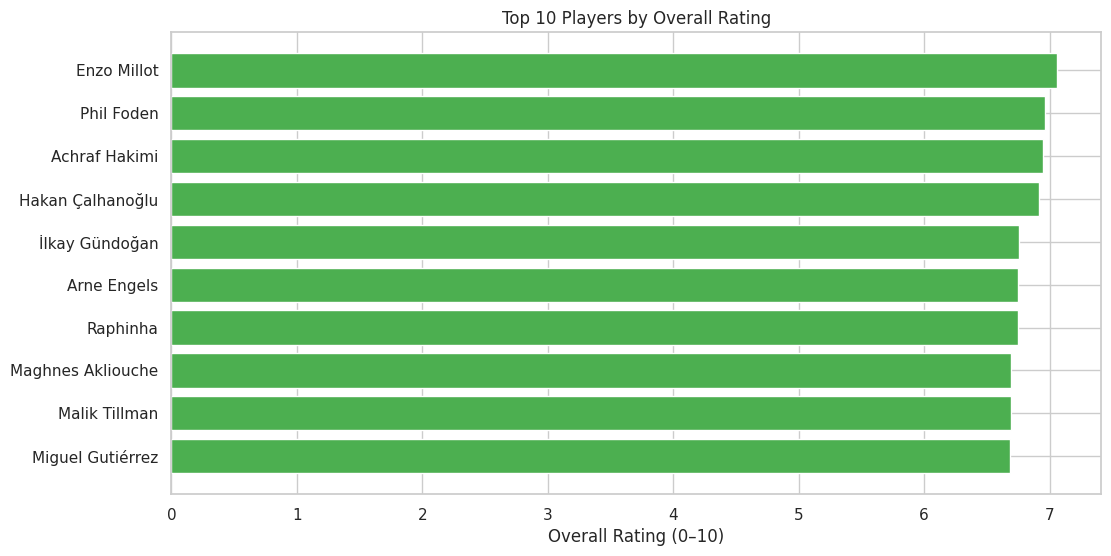

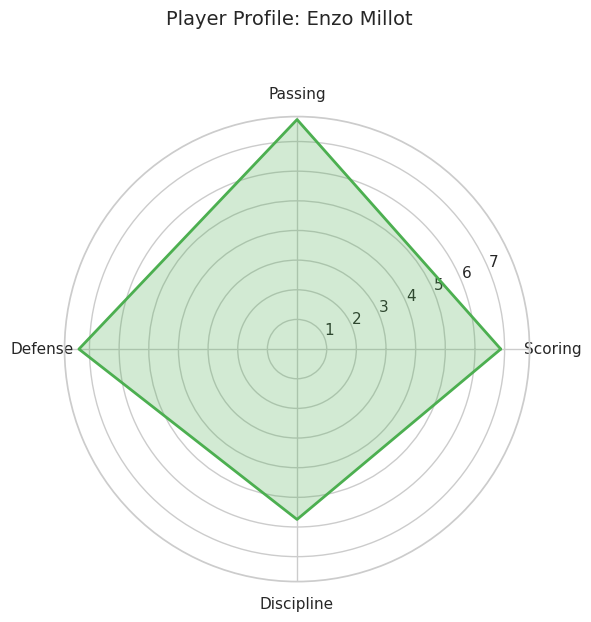

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

data_tables = [
    attacking_data,
    attempts_data,
    disciplinary_data,
    defending_data,
    distribution_data,
    goals_data,
    goalkeeping_data,
    key_stats_data,
    players_data,
    teams_data
]

# Start with an empty DataFrame
players_full_data_master = None

# Merge tables that have 'id_player'
for table in data_tables:
    if 'id_player' in table.columns:
        if players_full_data_master is None:
            # Initialize with the first table that has id_player
            players_full_data_master = table.copy()
        else:
            # Merge others on id_player
            players_full_data_master = players_full_data_master.merge(
                table,
                on='id_player',
                how='left'  # Keep all players from the master table
            )
# -----------------------------
# Initialize MinMaxScaler
# -----------------------------
scaler = MinMaxScaler()

# -----------------------------
# Map your actual columns to rating categories
# -----------------------------
SCORING_WEIGHTS = {
    'goals': 1.0,
    'inside_area': 1.0,
    'outside_area': 0.85,
    'right_foot': 0.9,
    'left_foot': 0.9,
    'head': 0.8,
    'other': 0.7,
    'penalties_scored': 0.4,
    'total_attempts': 0.5,
    'attempts_on_target': 0.8,
    'attempts_off_target': 0.3,
    'blocked': 0.2
}

PASSING_WEIGHTS = {
    'passing_accuracy(%)': 1.0,
    'passes_completed': 0.9,
    'passes_attempted': 0.4,
    'crossing_accuracy(%)': 0.9,
    'crosses_completed': 0.8,
    'crosses_attempted': 0.4,
    'free_kick_taken': 0.5,
    'matches_appareance': 0.2
}

DEFENSE_WEIGHTS = {
    'balls_recovered': 0.9,
    'tackles_won': 1.0,
    'tackles': 0.7,
    'tackles_lost': 0.2,
    'clearance_attempted': 0.6,
    # 'def_index_defense' missing, skip if not present
}

DISCIPLINE_WEIGHTS = {
    'fouls_committed': 1.0,
    'yellow_cards': 1.2,
    'red_cards': 1.5
}

# -----------------------------
# Helper functions
# -----------------------------
def zscore(series):
    std = series.std(ddof=0)
    return (series - series.mean()) / std if std != 0 else np.zeros(len(series))

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def zscore_sigmoid(series):
    return sigmoid(zscore(series))

def weighted_row_mean(df, weights_dict):
    cols, weights = [], []
    for col, w in weights_dict.items():
        if col in df.columns:
            cols.append(col)
            weights.append(w)
    if not cols:
        return np.zeros(len(df))
    return np.average(df[cols].values, axis=1, weights=np.array(weights))

# -----------------------------
# Convert numeric columns
# -----------------------------
all_columns = list(SCORING_WEIGHTS.keys()) + list(PASSING_WEIGHTS.keys()) + \
              list(DEFENSE_WEIGHTS.keys()) + list(DISCIPLINE_WEIGHTS.keys())

for col in all_columns:
    if col in players_full_data_master.columns:
        players_full_data_master[col] = pd.to_numeric(players_full_data_master[col], errors='coerce')

# Fill NaNs with 0
players_full_data_master = players_full_data_master.fillna(0)

# -----------------------------
# Apply zscore + sigmoid
# -----------------------------
for col in all_columns:
    if col in players_full_data_master.columns:
        players_full_data_master[col] = zscore_sigmoid(players_full_data_master[col])

# Invert discipline (lower is better)
for col in DISCIPLINE_WEIGHTS.keys():
    if col in players_full_data_master.columns:
        players_full_data_master[col] = 1 - players_full_data_master[col]

# -----------------------------
# Category ratings (0–10)
# -----------------------------
players_full_data_master['scoring_rating'] = weighted_row_mean(players_full_data_master, SCORING_WEIGHTS) * 10
players_full_data_master['passing_rating'] = weighted_row_mean(players_full_data_master, PASSING_WEIGHTS) * 10
players_full_data_master['defense_rating'] = weighted_row_mean(players_full_data_master, DEFENSE_WEIGHTS) * 10
players_full_data_master['discipline_rating'] = weighted_row_mean(players_full_data_master, DISCIPLINE_WEIGHTS) * 10

# -----------------------------
# Overall rating
# -----------------------------
players_full_data_master['overall_rating'] = (
    0.35 * players_full_data_master['scoring_rating'] +
    0.30 * players_full_data_master['passing_rating'] +
    0.20 * players_full_data_master['defense_rating'] +
    0.15 * players_full_data_master['discipline_rating']
).clip(0, 10)

# -----------------------------
# Top 10 plot
# -----------------------------
top10 = players_full_data_master.sort_values('overall_rating', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top10['player_name'], top10['overall_rating'], color="#4CAF50")
plt.gca().invert_yaxis()
plt.xlabel('Overall Rating (0–10)')
plt.title('Top 10 Players by Overall Rating')
plt.show()

# -----------------------------
# Radar plot for best player
# -----------------------------
best_player = top10.iloc[0]

labels = ['Scoring', 'Passing', 'Defense', 'Discipline']
values = [
    best_player['scoring_rating'],
    best_player['passing_rating'],
    best_player['defense_rating'],
    best_player['discipline_rating']
]

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
values += values[:1]
angles = np.append(angles, angles[0])

fig = plt.figure(figsize=(6, 7))
ax = fig.add_subplot(111, polar=True)
ax.plot(angles, values, color="#4CAF50", linewidth=2)
ax.fill(angles, values, color="#4CAF50", alpha=0.25)
ax.set_thetagrids(angles[:-1]*180/np.pi, labels)
fig.suptitle(f"Player Profile: {best_player['player_name']}", fontsize=14, y=0.98)
plt.show()
